<a href="https://colab.research.google.com/github/RichaGaharwar/Walmart---Confidence-Interval-CLT/blob/main/Walmart_Confidence_Interval_%26_CLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **About Walmart**
---
Walmart is an American multinational retail corporation that operates a chain of supercenters, discount departmental stores, and grocery stores from the United States. Walmart has more than 100 million customers worldwide.

---
**Business Problem**

---

The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).

---
**Dataset**

---


The company collected the transactional data of customers who purchased products from the Walmart Stores during Black Friday.

The dataset has the following features:

* User_ID:	User ID
* Product_ID:	Product ID
* Gender:	Sex of User
* Age:	Age in bins
* Occupation:	Occupation(Masked)
* City_Category:	Category of the City (A,B,C)
* StayInCurrentCityYears:	Number of years stay in current city
* Marital_Status:	Marital Status
* ProductCategory:	Product Category (Masked)
* Purchase:	Purchase Amount




---

**What good looks like?**

---



* Import the dataset and do usual data analysis steps like checking the structure & characteristics of the dataset.
* Detect Null values & Outliers (using boxplot, “describe” method by checking the difference between mean and median, isnull etc.)
* do some data exploration steps like:

  * Tracking the amount spent per transaction of all the 50 million female customers, and all the 50 million male customers, calculate the average, and conclude the results.
  * Inference after computing the average female and male expenses.
  * Use the sample average to find out an interval within which the population average will lie. Using the sample of female customers you will calculate the interval within which the average spending of 50 million male and female customers may lie.
* Use the Central limit theorem to compute the interval. Change the sample size to observe the distribution of the mean of the expenses by female and male customers.
  * The interval that you calculated is called Confidence Interval. The width of the interval is mostly decided by the business: Typically 90%, 95%, or 99%. Play around with the width parameter and report the observations.
* conclude the results and check if the confidence intervals of average male and female spends are overlapping or not overlapping. How can Walmart leverage this conclusion to make changes or improvements?
* Perform the same activity for Married vs Unmarried and Age
  * For Age, you can try bins based on life stages: 0-17, 18-25, 26-35, 36-50, 51+ years.
* Give recommendations and action items to Walmart.



---


**Evaluation Criteria**


---



* Defining Problem Statement and Analyzing basic metrics (10 Points)
  * Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), statistical summary
  * Non-Graphical Analysis: Value counts and unique attributes ​
  * Visual Analysis - Univariate & Bivariate
    * For continuous variable(s): Distplot, countplot, histogram for univariate analysis
    * For categorical variable(s): Boxplot
    * For correlation: Heatmaps, Pairplots
* Missing Value & Outlier Detection (10 Points)
* Business Insights based on Non- Graphical and Visual Analysis (10 Points)
  * Comments on the range of attributes
  * Comments on the distribution of the variables and relationship between them
  * Comments for each univariate and bivariate plot
* Answering questions (50 Points)
  * Are women spending more money per transaction than men? Why or Why not? (10 Points)
  * Confidence intervals and distribution of the mean of the expenses by female and male customers (10 Points)
  * Are confidence intervals of average male and female spending overlapping? How can Walmart leverage this conclusion to make changes or improvements? (10 Points)
  * Results when the same activity is performed for Married vs Unmarried (10 Points)
  * Results when the same activity is performed for Age (10 Points)
* Final Insights (10 Points) - Illustrate the insights based on exploration and CLT
  * Comments on the distribution of the variables and relationship between them
  * Comments for each univariate and bivariate plots
  * Comments on different variables when generalizing it for Population
* Recommendations (10 Points)
  * Actionable items for business. No technical jargon. No complications. Simple action items that everyone can understand

**colors**:
* Spark Yellow : '#FFC220'
* True Blue : '#0071CE'
* White : '#FFFFFF'

---

# **Exploratory Data Analysis**

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

walmart = pd.read_csv('/content/walmart.csv')

In [ ]:
walmart.shape

(550068, 10)

**Working on dataset with 10 features and 550k records**

In [ ]:
walmart.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
walmart.tail(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365
550067,1006039,P00371644,F,46-50,0,B,4+,1,20,490


In [ ]:
walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [5]:
walmart.isnull().values.any()

np.False_

* **No missing values found**
* **Some features need change of datatype:**
  * **occupation**
  * **product_category**
  * **marital status**

```
Features like occupation, product category & marital status are now categorical features.

```

In [ ]:
walmart['User_ID'] = walmart['User_ID'].astype(int)
walmart['Occupation'] = walmart['Occupation'].astype('category')
walmart['Product_Category'] = walmart['Product_Category'].astype('category')
walmart['Marital_Status'] = walmart['Marital_Status'].astype('category')

walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  object  
 2   Gender                      550068 non-null  object  
 3   Age                         550068 non-null  object  
 4   Occupation                  550068 non-null  category
 5   City_Category               550068 non-null  object  
 6   Stay_In_Current_City_Years  550068 non-null  object  
 7   Marital_Status              550068 non-null  category
 8   Product_Category            550068 non-null  category
 9   Purchase                    550068 non-null  int64   
dtypes: category(3), int64(2), object(5)
memory usage: 31.0+ MB


**Occupation, Product_category & Marital status are now categorical features**

In [ ]:
walmart['Purchase'].describe()

,Purchase
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


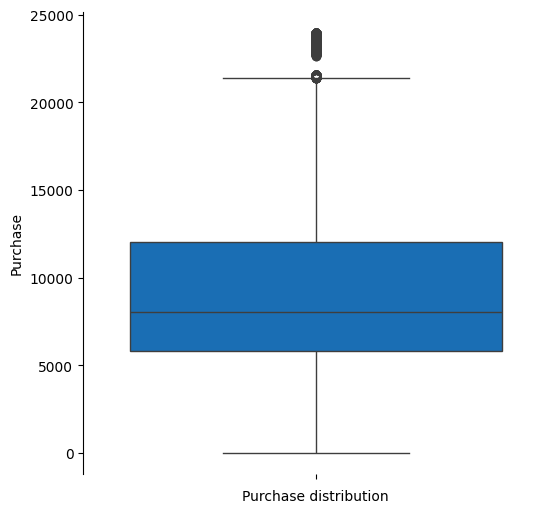

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (6, 6))
ax = plt.gca()
sns.boxplot(walmart['Purchase'], color = True_Blue)
plt.xlabel('Purchase distribution')
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

**What can be inferred from the purchase data?**

*   **max purchase amount is almost 24k and standard deviation is 5k ie. data has upper outlier**

*   **mean > median ie., the data is right skewed, meaning a few massive, expensive purchases are pulling the average up.**

* **75% of all purchases are equal to or below 12k. It means the top 25% of your biggest spenders are buying items above 12k.**

Text(0.5, 1.0, 'Gender Distribution')

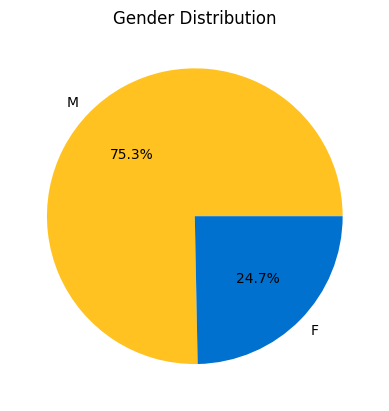

In [ ]:
plt.pie(x=walmart['Gender'].value_counts(), labels=walmart['Gender'].value_counts().index, colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('Gender Distribution')

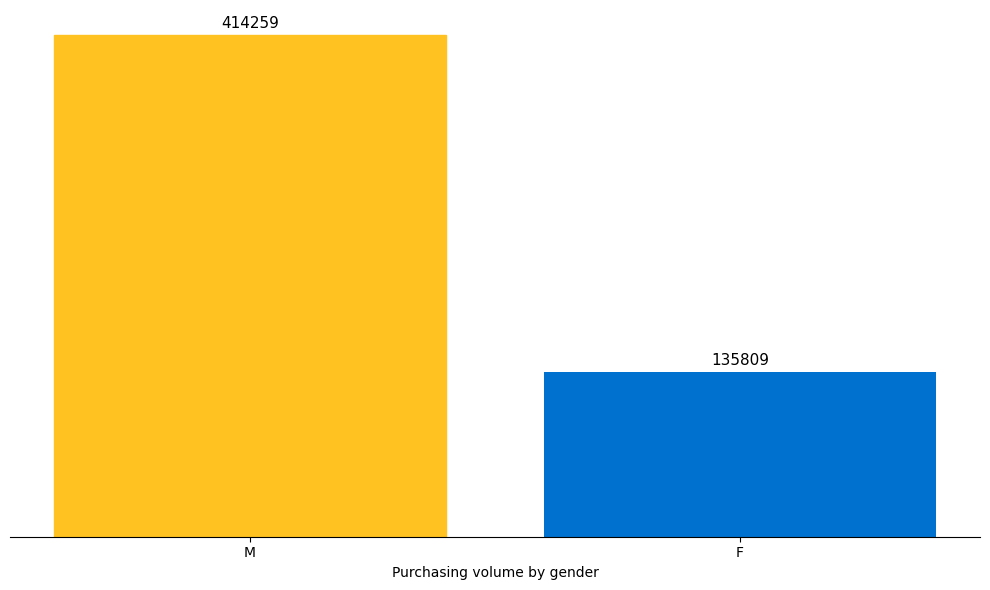

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (10, 6))
ax = plt.gca()
bars = plt.bar(walmart['Gender'].value_counts().index, walmart['Gender'].value_counts().values, color = True_Blue)
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding=3, fontsize=11)
plt.xlabel('Purchasing volume by gender')
plt.xticks(rotation = 0)

top_1_indices = np.argsort(walmart['Gender'].value_counts().values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

**The dataset has 24.7% female customers and 75.3% male customers, ie. 414k male customers and 135k female customers**

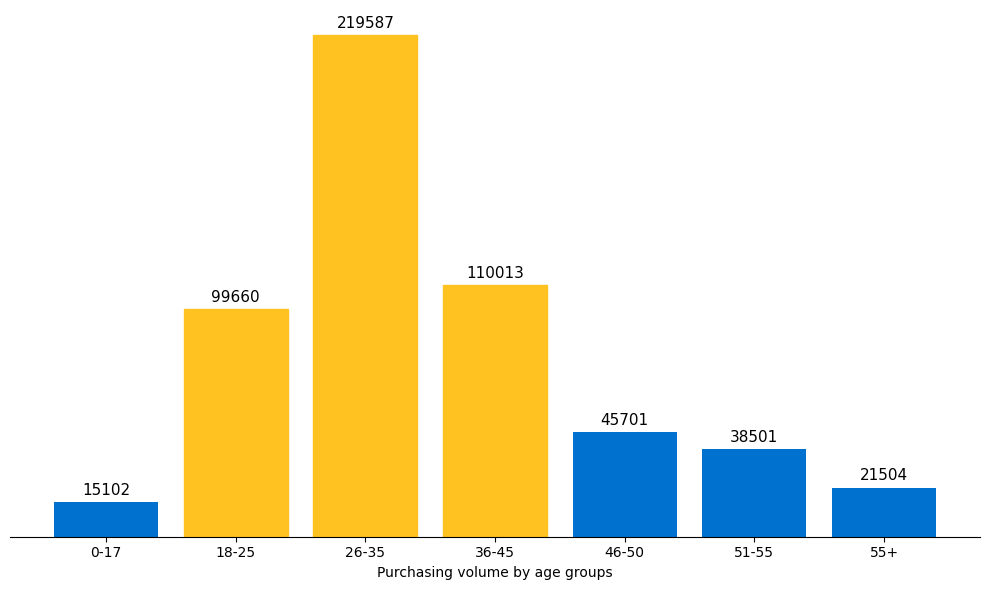

In [ ]:
age_counts = walmart['Age'].value_counts().sort_index()

Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (10, 6))
bars = plt.bar(age_counts.index.astype(str), age_counts.values, color=True_Blue)
ax = plt.gca()
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding=3, fontsize=11)
plt.xlabel('Purchasing volume by age groups')
plt.ylabel('purchase_amount')
plt.xticks(rotation = 0)

top_3_indices = np.argsort(age_counts.values)[-3:]
for idx in top_3_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

**customers between the ages of 26-35 are walmart's target customers with highest volume of purchases**

**18-25 year olds and 36-45 year olds are the second best age groups to target.**

In [ ]:
np.sort(walmart['Occupation'].unique())

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20], dtype=object)

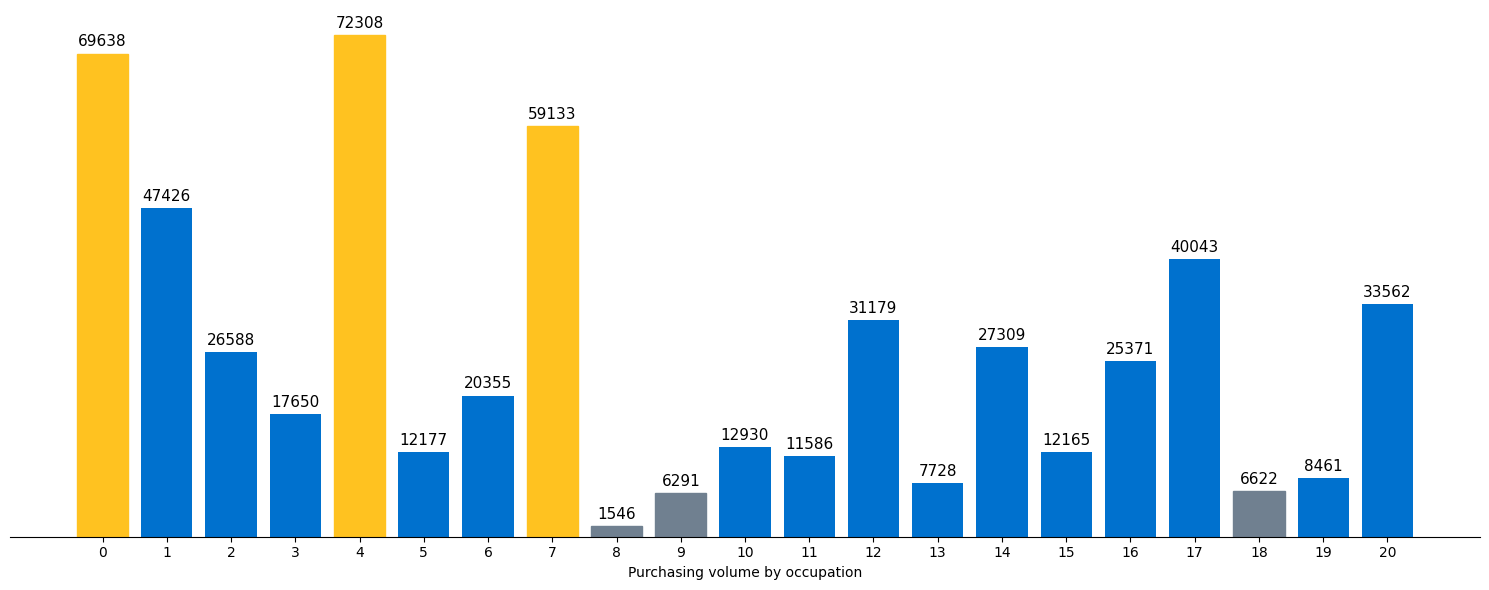

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'
Grey = '#708090'

plt.figure(figsize = (15, 6))
ax = plt.gca()
bars = plt.bar(walmart['Occupation'].value_counts().index, walmart['Occupation'].value_counts().values, color = True_Blue)
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding=3, fontsize=11)
plt.title('')
plt.xlabel('Purchasing volume by occupation')
plt.ylabel('purchase_amount')
plt.xticks(walmart['Occupation'].value_counts().index.astype(int))

top_3_indices = np.argsort(walmart['Occupation'].value_counts().values)[-3:]
for idx in top_3_indices:
    bars[idx].set_color(Spark_Yellow)

bottom_3_indices = np.argsort(walmart['Occupation'].value_counts().values)[:3:]
for idx in bottom_3_indices:
    bars[idx].set_color(Grey)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

**There are 21 different occupations of customers.**
**occupations of most spending customers are:**
  * **0, 4, 7**
**occupations of least spending customers are:**
  * **8, 9, 18**

In [ ]:
city = walmart['City_Category'].value_counts().sort_index()

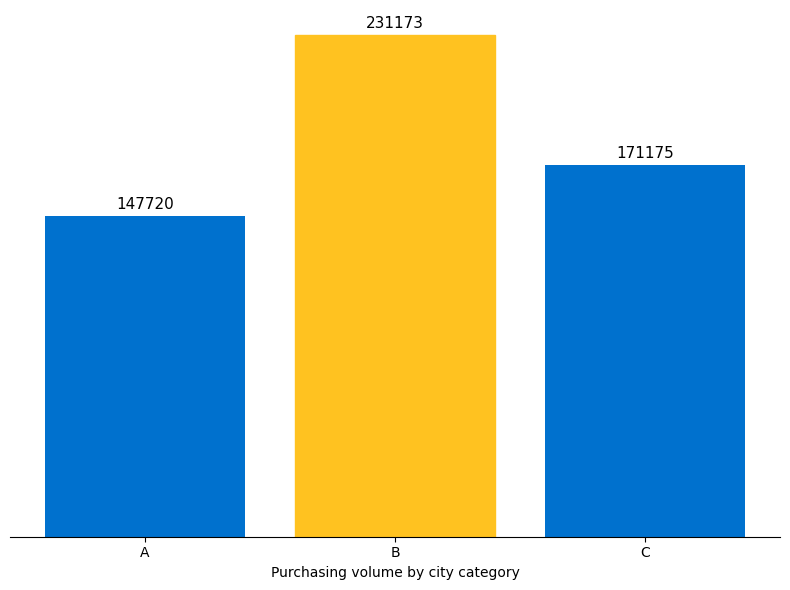

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (8, 6))
ax = plt.gca()
bars = plt.bar(city.index, city.values, color = True_Blue)
plt.xlabel('Purchasing volume by city category')
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)
plt.xticks(rotation = 0)

top_1_indices = np.argsort(city.values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

**Walmart's customers are spread across 3 different city categories.**

**Customers who spend the most come from city category B**

In [ ]:
stay_in_city = walmart['Stay_In_Current_City_Years'].value_counts().sort_index()
stay_in_city

,count
Stay_In_Current_City_Years,
0,74398
1,193821
2,101838
3,95285
4+,84726


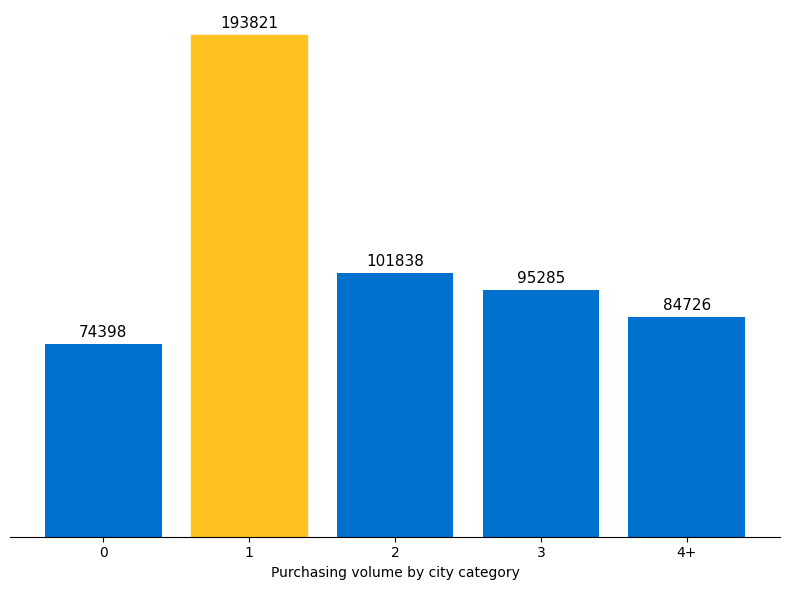

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (8, 6))
ax = plt.gca()
bars = plt.bar(stay_in_city.index, stay_in_city.values, color = True_Blue)
plt.xlabel('Purchasing volume by city category')
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)
plt.xticks(rotation = 0)

top_1_indices = np.argsort(stay_in_city.values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

**Customers with a 1-to-2-year tenure make the most purchases**

In [ ]:
marital_status = walmart['Marital_Status'].value_counts()

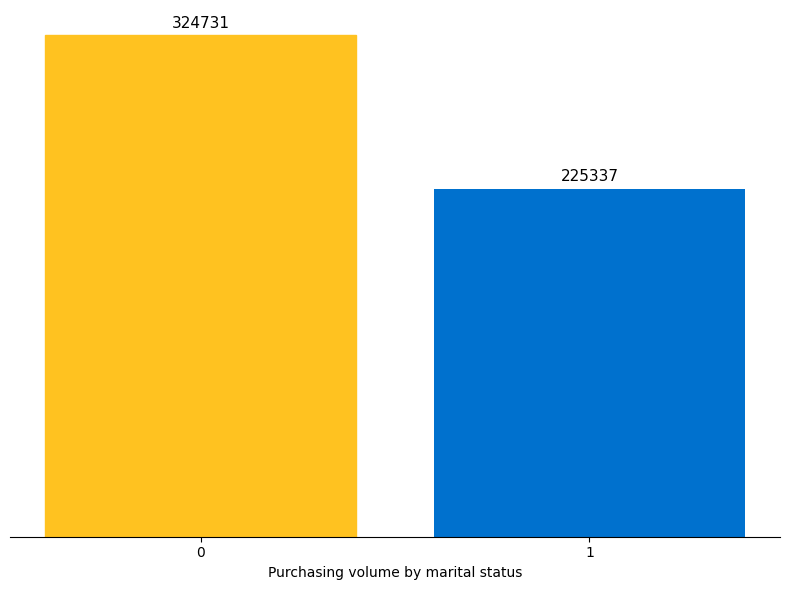

In [ ]:
from matplotlib import legend
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (8, 6))
ax = plt.gca()
bars = plt.bar(marital_status.index, marital_status.values, color = True_Blue)
plt.xlabel('Purchasing volume by marital status')
plt.xticks(marital_status.index.astype(int))
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)

plt.xticks(rotation = 0)

top_1_indices = np.argsort(marital_status.values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

**Customers who are single make the most purchases**

In [ ]:
walmart['Product_Category'].unique()

array([3, 1, 12, 8, 5, 4, 2, 6, 14, 11, 13, 15, 7, 16, 18, 10, 17, 9, 20,
       19], dtype=object)

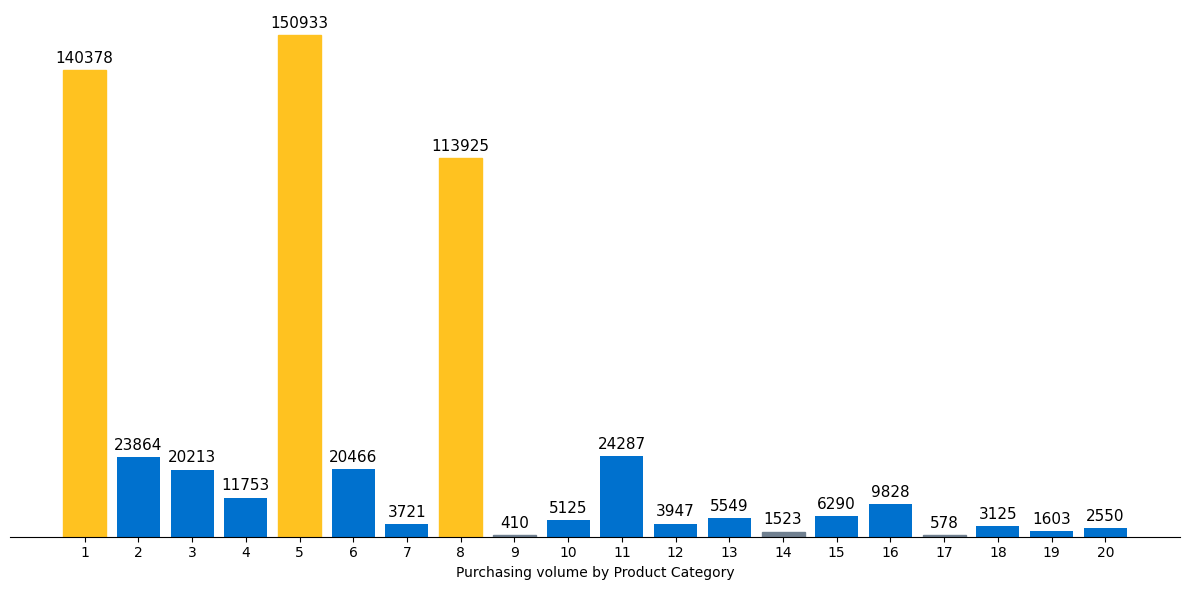

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'
Grey = '#708090'

prod_counts = walmart['Product_Category'].value_counts()

plt.figure(figsize = (12, 6))
ax = plt.gca()
bars = plt.bar(prod_counts.index, prod_counts.values, color = True_Blue)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)
ax.get_yaxis().set_visible(False)

plt.xticks(prod_counts.index.astype(int))

plt.xlabel('Purchasing volume by Product Category')

top_3_indices = np.argsort(walmart['Product_Category'].value_counts().values)[-3:]
for idx in top_3_indices:
    bars[idx].set_color(Spark_Yellow)

bottom_3_indices = np.argsort(walmart['Product_Category'].value_counts().values)[:3:]
for idx in bottom_3_indices:
    bars[idx].set_color(Grey)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

---

# **EDA Conclusion:**

---

**Working on dataset with 10 features and 550k records**

---

* **No missing values found**
* **change the datatype:**
  * **occupation**
  * **product_category**
  * **marital status**

---

**Occupation, Product_category & Marital status are now categorical features**

---

**Inferrence from the purchase data:**

*   **max purchase amount is almost 24k and standard deviation is 5k ie. data has upper outlier**

*   **mean > median ie., the data is right skewed, meaning a few massive, expensive purchases are pulling the average up.**

* **75% of all purchases are equal to or below 12k. It means the top 25% of your biggest spenders are buying items above 12k.**

---

**There are 24.7% female customers and 75.3% male customers, ie. 414k male customers and 135k female customers**

---
**customers between the ages of 26-35 are walmart's target customers with highest volume of purchases**

**18-25 year olds and 36-45 year olds are the second best age groups to target.**

---
**There are 21 different occupations of customers.**

**occupations of most spending customers are: 0, 4, 7**

**occupations of least spending customers are: 8, 9, 18**

---
**Walmart's customers are spread across 3 different city categories.**

**Customers who spend the most come from city category B**

---
**Customers with a 1-to-2-year tenure make the most purchases**

---
**Customers who are single make the most purchases**

---
**Most frequently purchased product categories are: 1, 5, 8.**

**Least frequent purchsed product categories are: 9, 14, 17.**

---

# **Walmart wants to understand if the spending habits differ in:**

---

  * **male and female customers**
  * **married and single customers**
  * **different age groups**
  * **different city category**
  

---

# **Analysis based on gender**

---

In [ ]:
customer_distribution_by_gender = walmart['User_ID'].groupby(walmart['Gender']).count().reset_index()
total_female_customers = customer_distribution_by_gender[customer_distribution_by_gender['Gender']=='F']
total_male_customers = customer_distribution_by_gender[customer_distribution_by_gender['Gender']=='M']

In [ ]:
total_female_customers.head()

,Gender,User_ID
0,F,135809


In [ ]:
customer_distribution_by_gender

,Gender,User_ID
0,F,120636
1,M,368545


In [ ]:
unique_customers = walmart['User_ID'].groupby(walmart['Gender']).nunique().reset_index('Gender')
unique_female_customers = unique_customers[unique_customers['Gender']=='F']
unique_male_customers = unique_customers[unique_customers['Gender']=='M']

In [ ]:
unique_customers.sum().value_counts()

,count
FM,1
5891,1


In [ ]:
unique_customers

,Gender,User_ID
0,F,1666
1,M,4225


In [ ]:
avg_purchase_qnt_customer = (walmart['User_ID'].count()/walmart['User_ID'].nunique()).round(2)
print(f"average number of purchases per customer: {avg_purchase_qnt_customer}")

average number of purchases per customer: 93.37


**Average number of purchases per customer: 93.37**

In [ ]:
avg_purchage_qnt_female = (total_female_customers['User_ID'].iloc[0] / unique_female_customers['User_ID'].iloc[0]).round(2)
print(f" Average number of purchases per female customers: {avg_purchage_qnt_female}")

 Average number of purchases per female customers: 81.52


In [ ]:
avg_purchage_qnt_female = (total_female_customers['User_ID']/ unique_female_customers['User_ID']).round(2)
print(f" Average number of purchases per female customers: {avg_purchage_qnt_female.iloc[0]}")

 Average number of purchases per female customers: 81.52


In [ ]:
avg_purchage_qnt_female

,User_ID
0,81.52


**Average number of purchases per female customers: 81.51**

In [ ]:
avg_purchage_qnt_male = (total_male_customers['User_ID'].iloc[0] / unique_male_customers['User_ID'].iloc[0]).round(2)
print(f"Average number of purchses per male customers: {avg_purchage_qnt_male}")

Average number of purchses per male customers: 87.23


**Average number of purchses per male customers: 98.04**

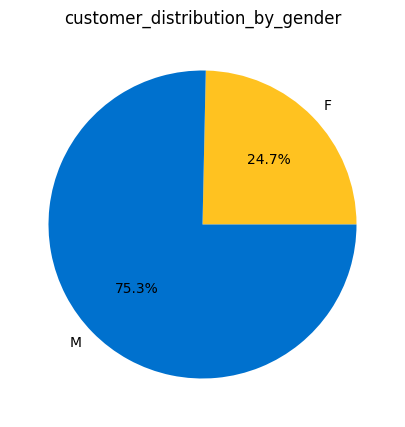

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(x=customer_distribution_by_gender['User_ID'], labels=customer_distribution_by_gender['Gender'], colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('customer_distribution_by_gender')
plt.show()

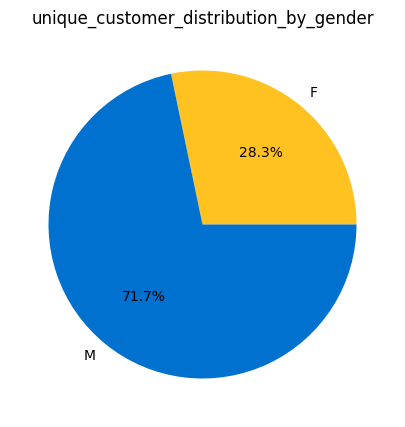

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(x=unique_customers['User_ID'], labels=unique_customers['Gender'], colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('unique_customer_distribution_by_gender')
plt.show()

**28.3% unique female customers contribute to 24.7% of the total purchses.**

**71.7% unique male customers contribute to 75.3% of the total purchses.**

In [ ]:
walmart['Purchase'].sum()

np.int64(4563410267)

**Average purchase amount per transaction by Gender**

In [ ]:
avg_fem_pur = walmart[walmart['Gender']=='F']['Purchase'].mean().round(2)
print(f"Average purchase amount of female customers: {avg_fem_pur}")

Average purchase amount of female customers: 8799.63


**Average purchase amount of female customers: 8734.57**

In [ ]:
avg_men_pur = (walmart[walmart['Gender']=='M']['Purchase'].mean()).round(2)
print(f"Average purchase amount of male customers: {avg_men_pur}")

Average purchase amount of male customers: 9501.85


**Average purchase amount of male customers: 9437.53**

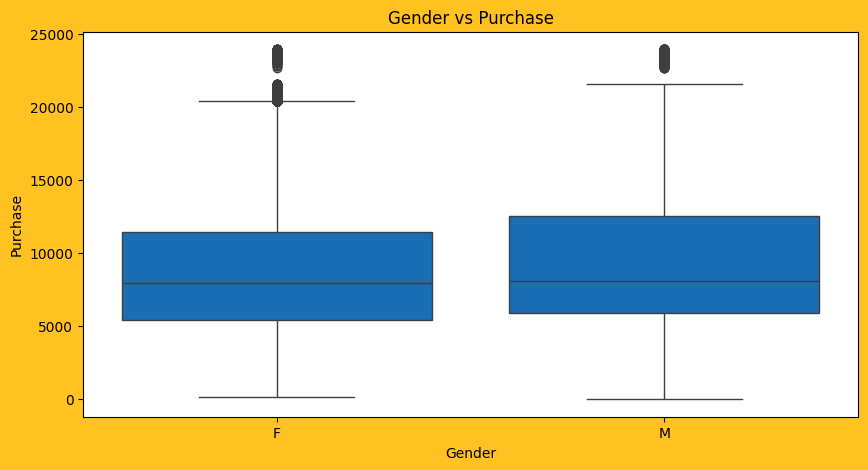

In [ ]:
plt.figure(figsize=(10,5), facecolor='#FFC220')
sns.boxplot(x=walmart['Gender'], y=walmart['Purchase'], color='#0071CE')
plt.xlabel('Gender')
plt.ylabel('Purchase')
plt.title('Gender vs Purchase')
plt.show()

**Confidence Interval for Average Purchase by Gender**

Now, let's calculate the 95% confidence interval for the average purchase amount for both female and male customers. This will give us a range within which the true population mean is likely to fall.

```
Let's seperate the dataset based on gender
```



In [ ]:
female_customers = walmart[walmart['Gender']=='F']
male_customers = walmart[walmart['Gender']=='M']

In [ ]:
female_customers.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
14,1000006,P00231342,F,51-55,9,A,1,0,5,5378


In [ ]:
import scipy.stats as st

female_mean = female_customers['Purchase'].mean()
female_std = female_customers['Purchase'].std()
female_n = len(female_customers)
female_ci = st.norm.interval(confidence = 0.95, loc = female_mean, scale = female_std/np.sqrt(female_n))

print(f"95% confidence interval for female purchases: {female_ci}")

95% confidence interval for female purchases: (np.float64(8773.01402559725), np.float64(8826.246725753923))


In [ ]:
male_customers.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686


In [ ]:
male_mean = male_customers['Purchase'].mean()
male_std = male_customers['Purchase'].std()
male_n = len(male_customers)
male_ci = st.norm.interval(confidence = 0.95, loc = male_mean, scale = male_std/np.sqrt(male_n))

print(f"95% confidence interval for male purchases: {male_ci}")

95% confidence interval for male purchases: (np.float64(9485.544049100845), np.float64(9518.149160683577))


---

Let's use the Central limit theorem to compute the Confidence Interval. we'll change the sample size to observe the distribution of the mean of the expenses by female and male customers.
The width of the interval is mostly decided by the business:Typically 90%, 95%, or 99%.
We'll play around with the width parameter and report the observations.

---

In [ ]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['F']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000      F              90%      8813.54         14.9832      8788.90      8838.19           49.29
         100000      F              95%      8813.54         14.9832      8784.17      8842.91           58.73
         100000      F              99%      8813.54         14.9832      8774.95      8852.13           77.19


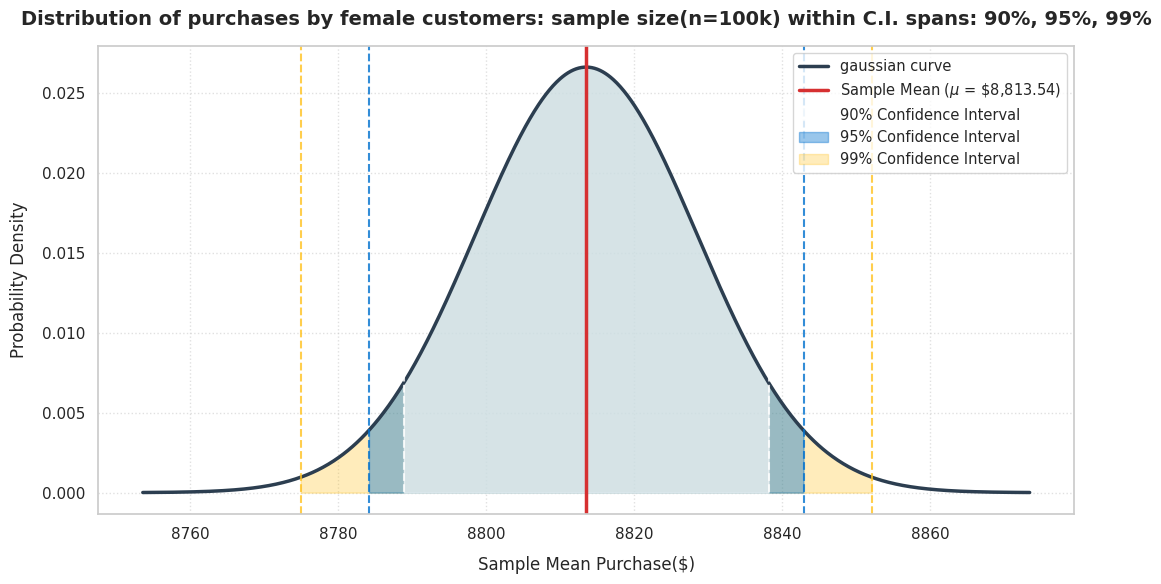

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'F')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'F'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by female customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [300000] # Include all desired sample sizes here
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['F']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000      F              90%      8811.68          8.6375      8797.47      8825.89           28.41
         300000      F              95%      8811.68          8.6375      8794.75      8828.61           33.86
         300000      F              99%      8811.68          8.6375      8789.43      8833.93           44.50


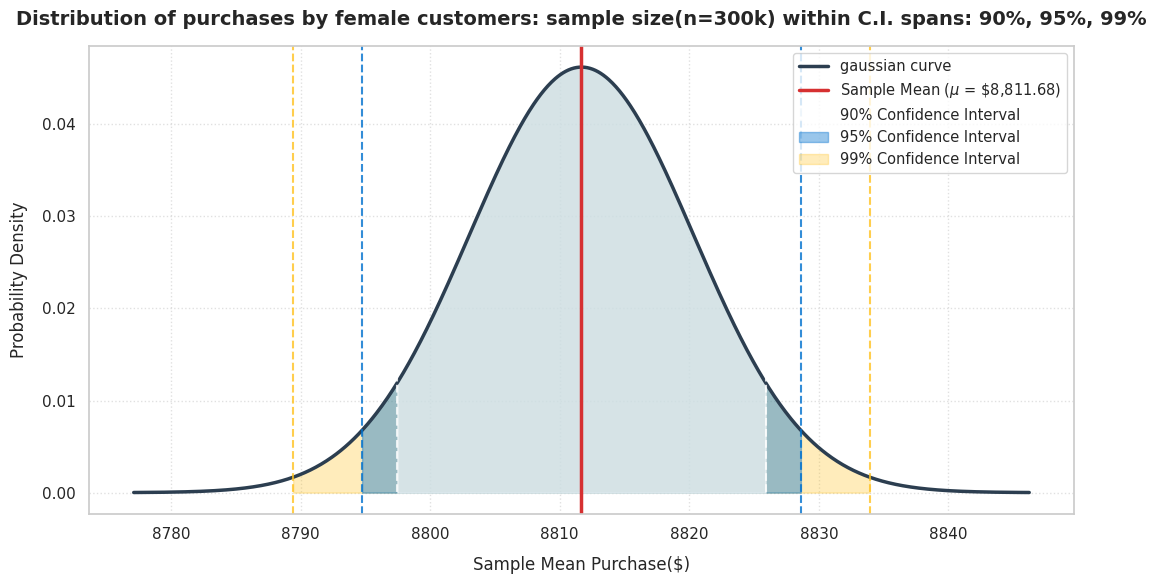

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'F')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'F'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by female customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['F']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        sts_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(sem, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000      F              90%      8804.43          8.6375      8790.22      8818.64           28.41
         500000      F              95%      8804.43          8.6375      8787.50      8821.36           33.86
         500000      F              99%      8804.43          8.6375      8782.18      8826.68           44.50


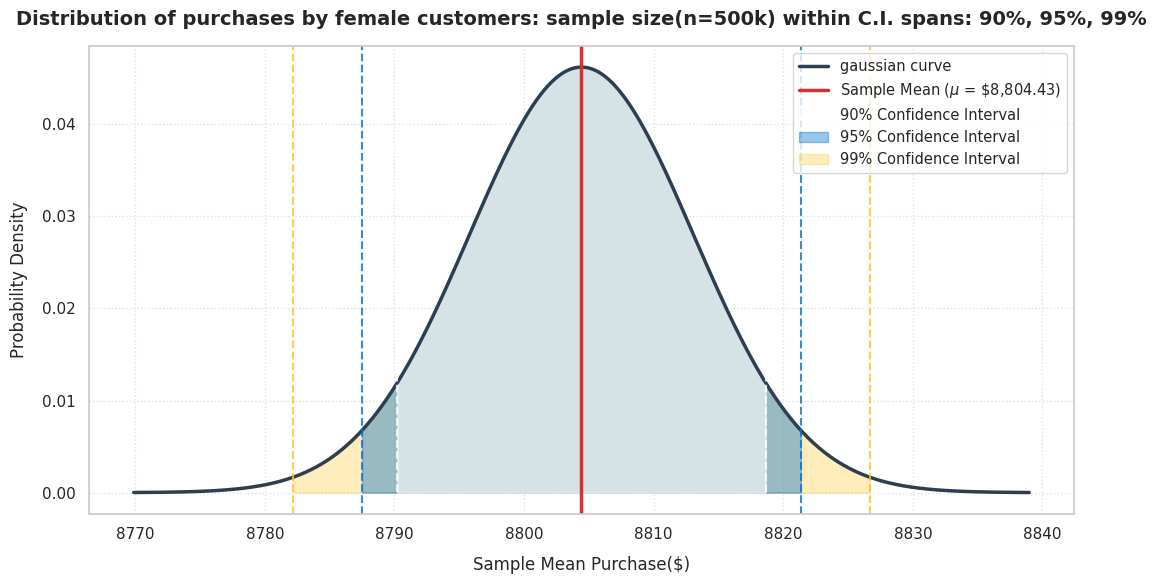

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'F')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'F'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    std_err = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by female customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['M']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000      M              90%       9521.9         15.9542      9495.66      9548.14           52.48
         100000      M              95%       9521.9         15.9542      9490.63      9553.17           62.54
         100000      M              99%       9521.9         15.9542      9480.81      9563.00           82.19


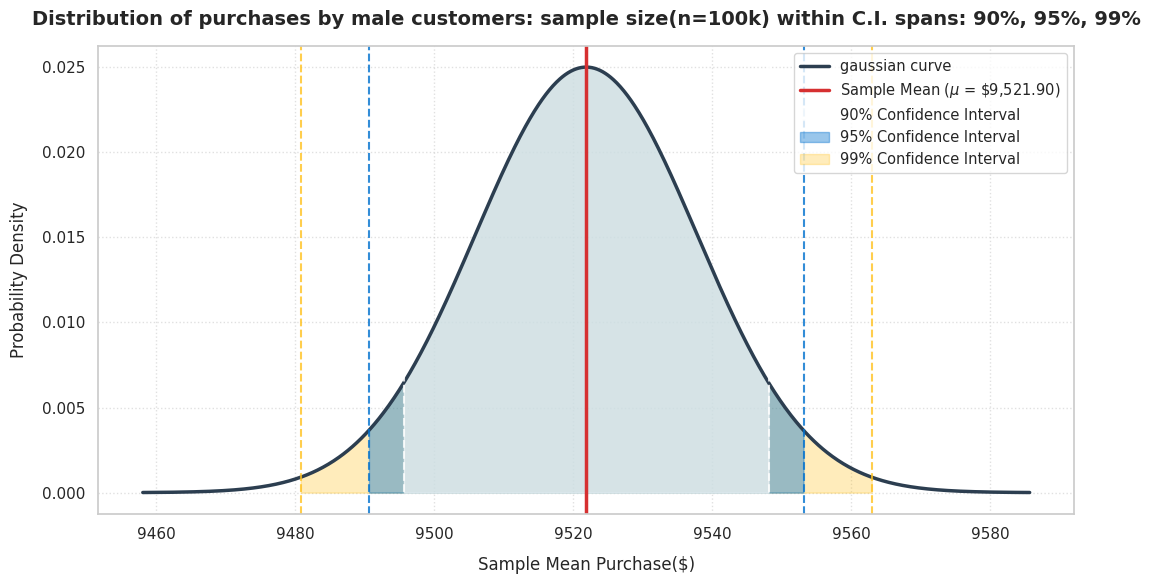

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'M')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'M'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    std_err = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by male customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [300000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['M']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err


            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000      M              90%      9508.45           9.206      9493.31      9523.59           30.29
         300000      M              95%      9508.45           9.206      9490.41      9526.49           36.09
         300000      M              99%      9508.45           9.206      9484.74      9532.16           47.43


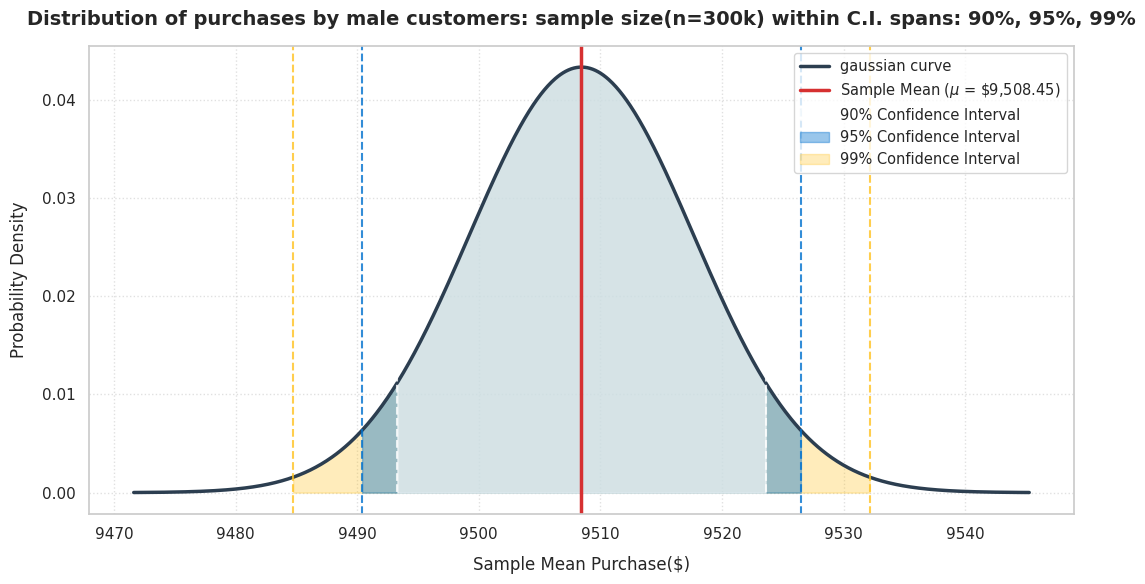

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'M')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'M'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    std_err = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by male customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for gender in ['M']:

        gender_pop = walmart[walmart['Gender'] == gender]['Purchase']

        sample = gender_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Gender': gender,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Gender Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000      M              90%      9503.18          7.1373      9491.44      9514.92           23.48
         500000      M              95%      9503.18          7.1373      9489.19      9517.16           27.98
         500000      M              99%      9503.18          7.1373      9484.79      9521.56           36.77


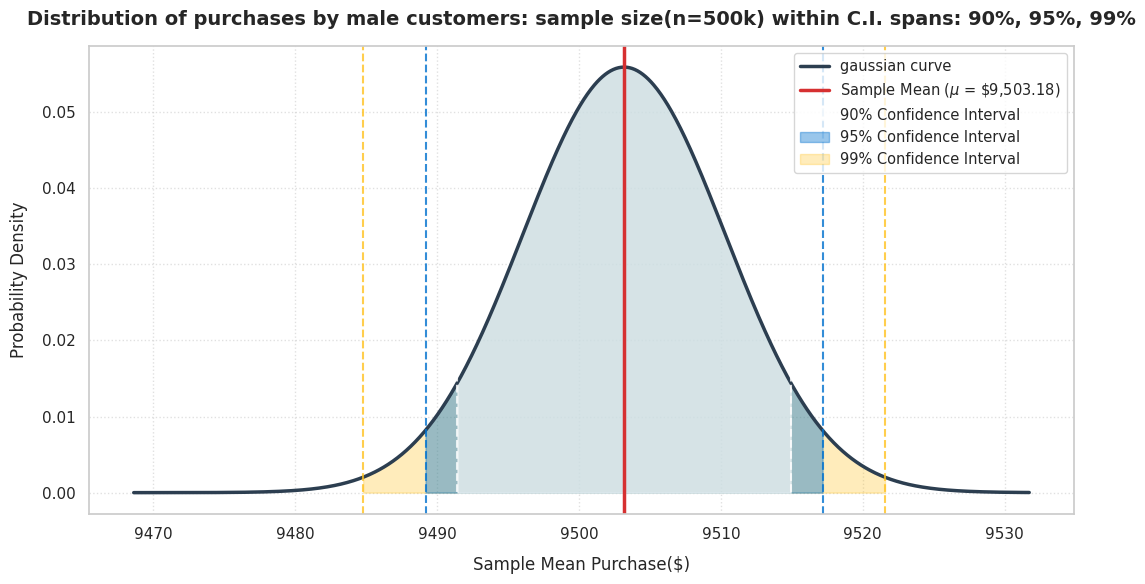

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Gender'] == 'M')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Gender = 'M'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    std_err = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * sem, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err
                                )

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by male customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

**Using the sample of female and male customers you will calculate the interval within which the average spending of 50 million male and female customers may lie.**

**Let's check if the confidence intervals of average male and female spends are overlapping or not overlapping.**

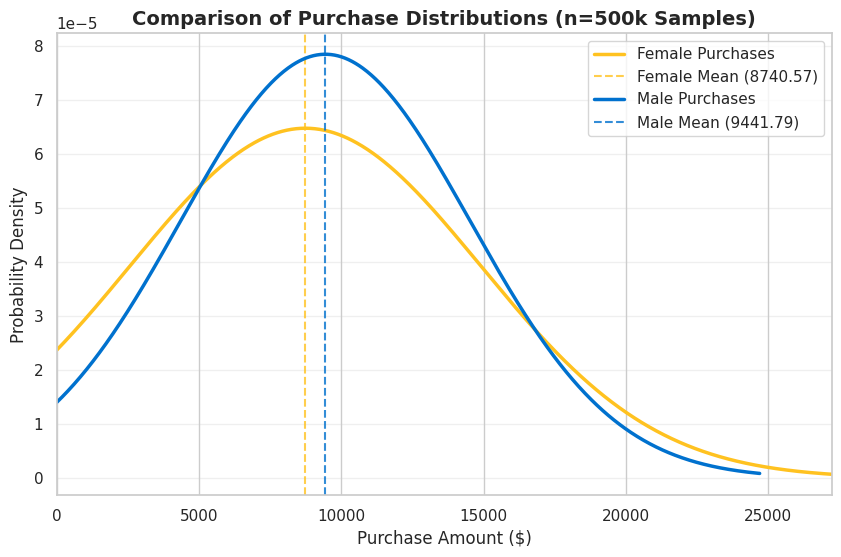

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set up the figure
plt.figure(figsize=(10, 6))

# ---- Curve 1: Female Purchases ----

mu1, sigma1 = 8740.57, 6158.90

x1 = np.linspace(0, mu1 + 3*sigma1, 1000)
plt.plot(x1, stats.norm.pdf(x1, mu1, sigma1), label='Female Purchases', color='#FFC220', lw=2.5)
plt.axvline(mu1, color='#FFC220', linestyle='--', alpha=0.8, lw=1.5, label=f'Female Mean ({mu1:.2f})')

# ---- Curve 2: Male Purchases ----

mu2, sigma2 = 9441.79, 5084.10

x2 = np.linspace(0, mu2 + 3*sigma2, 1000)
plt.plot(x2, stats.norm.pdf(x2, mu2, sigma2), label='Male Purchases', color='#0071CE', lw=2.5)
plt.axvline(mu2, color='#0071CE', linestyle='--', alpha=0.8, lw=1.5, label=f'Male Mean ({mu2:.2f})')

plt.title('Comparison of Purchase Distributions (n=500k Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Amount ($)')
plt.ylabel('Probability Density')
plt.xlim(0, max(x1.max(), x2.max()))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

---

# **Conclusion: gender based analysis**

---

* **Total customers : 550k**
  * **135809 (F)**
  * **414259 (M)**

* **Unique customers : 5891**
  * **1666 (F)**
  * **4225 (M)**
  
* **The average number of purchases per customer : 93**
  * **Female : 81.52**
  * **Male : 98.05**

**Average purchase amount per transaction by Gender**
**Average purchase amount of female customers: 8734.57**
**Average purchase amount of male customers: 9437.53**


* **Females contribute to 1/4 of total transactions**
* **Males contribute to 3/4 of the total transactions.**

* **71% of men contributes to 75% of revenue**

* **28% of women contributes to 25% of revenue**


**Males spend slightly more on average per transaction.**

```
Statistically across this entire dataset, the average transaction for men sits around 9.264,
while for women it sits around 8.770.
```

**Both genders are almost equally unpredictable, but males have a marginally wider spread.**

```
The heights of the blue boxes (the IQR, representing the middle 50% of purchases) are incredibly similar.
Both men and women have a wide variety of purchasing behaviors—ranging from small impulse buys to large retail hauls—
meaning neither group has a strictly "predictable" ticket size.
```

**The spending habits are largely identical.**

```
The two boxes overlap almost perfectly on the y-axis.
While male customers represent a massive volume of the overall transactions in this dataset (roughly 75%),
the actual amount spent per transaction does not vary drastically between genders
```
**95% confidence interval for female purchases: 8709 - 8759**

**95% confidence interval for male purchases: 9422 - 9453**

**The confidence intervals for two groups do not overlap, it is the statistical equivalent of saying: These two groups are definitively and genuinely different.**

**Men Spand More Than Women on Average**

```
We can say with extreme confidence (95% or higher) that the true average
spending of all male Walmart customers in this population is higher than the
true average spending of all female Walmart customers.
```

  * **The maximum plausible average for females is about $8,765.**

  * **The minimum plausible average for males is about $9,422.**

  * **There is a clear, unbridgeable gap of roughly $650 between them.**
#**Gender alone is a very weak predictor of how much an individual customer will spend on a single purchase.**

---

# **Analysis based on marital status**

---

In [ ]:
customer_distribution_by_marital_status = walmart['User_ID'].groupby(walmart['Marital_Status']).count().reset_index()
total_married_customers = customer_distribution_by_marital_status[customer_distribution_by_marital_status['Marital_Status']=='1']
total_single_customers = customer_distribution_by_marital_status[customer_distribution_by_marital_status['Marital_Status']=='0']

In [ ]:
customer_distribution_by_marital_status

,Marital_Status,User_ID
0,0,288896
1,1,200285


* **Total customers : 550k**
  * **324731 (single)**
  * **225337 (married)**

In [ ]:
unique_customers = walmart['User_ID'].groupby(walmart['Marital_Status']).nunique().reset_index()
unique_married_customers = unique_customers[unique_customers['Marital_Status']=='1']
unique_single_customers = unique_customers[unique_customers['Marital_Status']=='0']


In [ ]:
unique_customers

,Marital_Status,User_ID
0,0,3417
1,1,2474


* **Unique customers : 5891**
  * **3417 (single)**
  * **2474 (Married)**

In [ ]:
total_married_customers = customer_distribution_by_marital_status[customer_distribution_by_marital_status['Marital_Status']==1]
unique_married_customers = unique_customers[unique_customers['Marital_Status']==1]
avg_purchage_married = (total_married_customers['User_ID'].iloc[0] / unique_married_customers['User_ID'].iloc[0]).round(2)
print(f" Average number of purchases by married customers: {avg_purchage_married}")

 Average number of purchases by married customers: 80.96


**Average number of purchases by married customers: 91.08**

In [ ]:
total_single_customers = customer_distribution_by_marital_status[customer_distribution_by_marital_status['Marital_Status']==0]
unique_single_customers = unique_customers[unique_customers['Marital_Status']==0]
avg_purchage_single = (total_single_customers['User_ID'].iloc[0] / unique_single_customers['User_ID'].iloc[0]).round(2)
print(f"Average number of purchses by single customers:{avg_purchage_single}")

Average number of purchses by single customers:84.55


**Average number of purchses by single customers:95.03**

* **The average number of purchases per customer : 93**
  * **married : 91.08**
  * **single : 95.03**


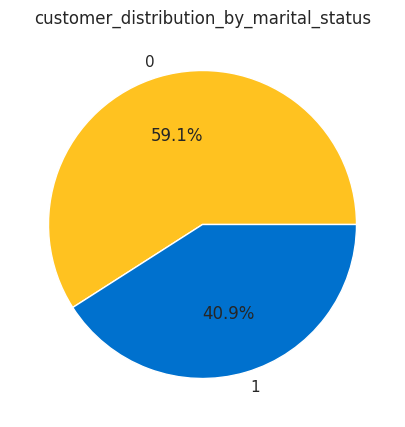

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(x=customer_distribution_by_marital_status['User_ID'], labels=customer_distribution_by_marital_status['Marital_Status'], colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('customer_distribution_by_marital_status')
plt.show()

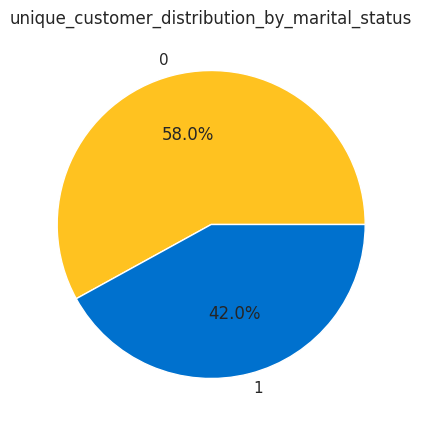

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(x=unique_customers['User_ID'], labels=unique_customers['Marital_Status'], colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('unique_customer_distribution_by_marital_status')
plt.show()

**59% single customers contribute to 58% of the total purchases.**

**41% married customers contributes to 42% of the total purchases.**

**Average purchase amount per transaction by Gender**

In [ ]:
avg_married_purchase  = (walmart[walmart['Marital_Status']==1]['Purchase'].mean()).round(2)
print(f"Average purchase amount of married customers: {avg_married_purchase}")

Average purchase amount of married customers: 9329.12


**Average purchase amount of married customers: 9261.17**

In [ ]:
avg_single_purchase = (walmart[walmart['Marital_Status']==0]['Purchase'].mean()).round(2)
print(f"Average purchase amount of single customers: {avg_single_purchase}")

Average purchase amount of single customers: 9328.37


**Average purchase amount of single customers: 9265.91**

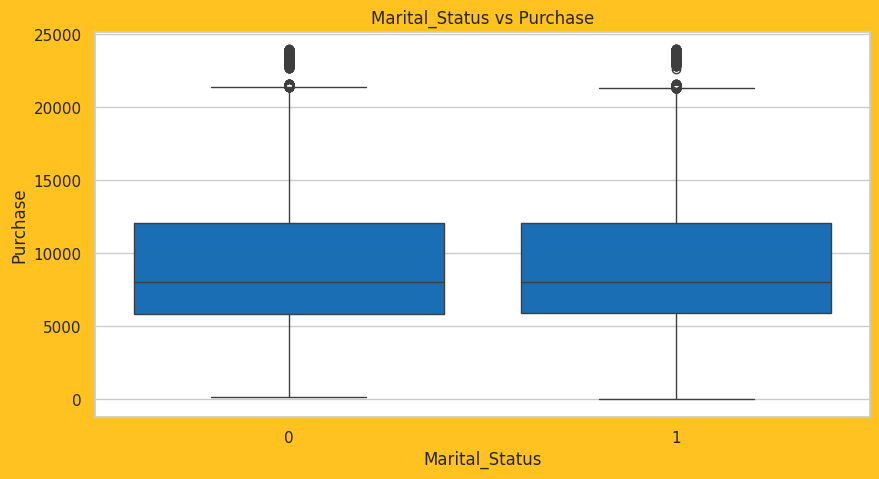

In [ ]:
plt.figure(figsize=(10,5), facecolor='#FFC220')
sns.boxplot(x=walmart['Marital_Status'], y=walmart['Purchase'], color='#0071CE')
plt.xlabel('Marital_Status')
plt.ylabel('Purchase')
plt.title('Marital_Status vs Purchase')
plt.show()

**Confidence Interval for Average Purchase by Gender**

Now, let's calculate the 95% confidence interval for the average purchase amount for both married and single customers. This will give us a range within which the true population mean is likely to fall.

```
Let's seperate the dataset based on marital status
```

In [ ]:
married_customers = walmart[walmart['Marital_Status']==1]
married_customers

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686
9,1000005,P00274942,M,26-35,20,A,1,1,8,7871
10,1000005,P00251242,M,26-35,20,A,1,1,5,5254
...,...,...,...,...,...,...,...,...,...,...
489176,1003416,P00057542,M,26-35,12,B,4+,1,3,8242
489177,1003416,P00010942,M,26-35,12,B,4+,1,1,19346
489178,1003416,P00283342,M,26-35,12,B,4+,1,5,7060
489179,1003416,P00016342,M,26-35,12,B,4+,1,1,8293


In [ ]:
import scipy.stats as st

married_mean = married_customers['Purchase'].mean()
married_std = married_customers['Purchase'].std()
married_n = len(married_customers)
married_ci = st.norm.interval(confidence = 0.95, loc = married_mean, scale = married_std/np.sqrt(married_n))

print(f"95% confidence interval for married purchases: {married_ci}")

95% confidence interval for married purchases: (np.float64(9307.350792518848), np.float64(9350.881017152371))


In [ ]:
single_customers = walmart[walmart['Marital_Status']==0]
single_customers

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
489161,1003415,P00110542,M,36-45,7,C,0,0,8,9912
489162,1003415,P00194442,M,36-45,7,C,0,0,5,7063
489163,1003415,P00255942,M,36-45,7,C,0,0,1,15295
489164,1003415,P00178342,M,36-45,7,C,0,0,8,7834


**95% confidence interval for married purchases: 9240 to 9281**

In [ ]:
single_mean = single_customers['Purchase'].mean()
single_std = single_customers['Purchase'].std()
single_n = len(single_customers)
single_ci = st.norm.interval(confidence = 0.95, loc = single_mean, scale = single_std/np.sqrt(single_n))

print(f"95% confidence interval for single purchases: {single_ci}")

95% confidence interval for single purchases: (np.float64(9310.190590197224), np.float64(9346.546007055767))


**95% confidence interval for single purchases: 9248 to 9283**

**Marital status, much like gender, is an incredibly weak predictor of individual purchase amounts.**

---

Let's use the Central limit theorem to compute the Confidence Interval. we'll change the sample size to observe the distribution of the mean of the expenses by married and single customers.
The width of the interval is mostly decided by the business:Typically 90%, 95%, or 99%.
We'll play around with the width parameter and report the observations.

---

In [ ]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for ms in [1]:

        ms_pop = walmart[walmart['Marital_Status'] == ms]['Purchase']

        sample = ms_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Marital_Status': ms,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)  Marital_Status Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000               1              90%      9306.37         15.7025      9280.55      9332.20           51.66
         100000               1              95%      9306.37         15.7025      9275.60      9337.15           61.55
         100000               1              99%      9306.37         15.7025      9265.93      9346.82           80.89


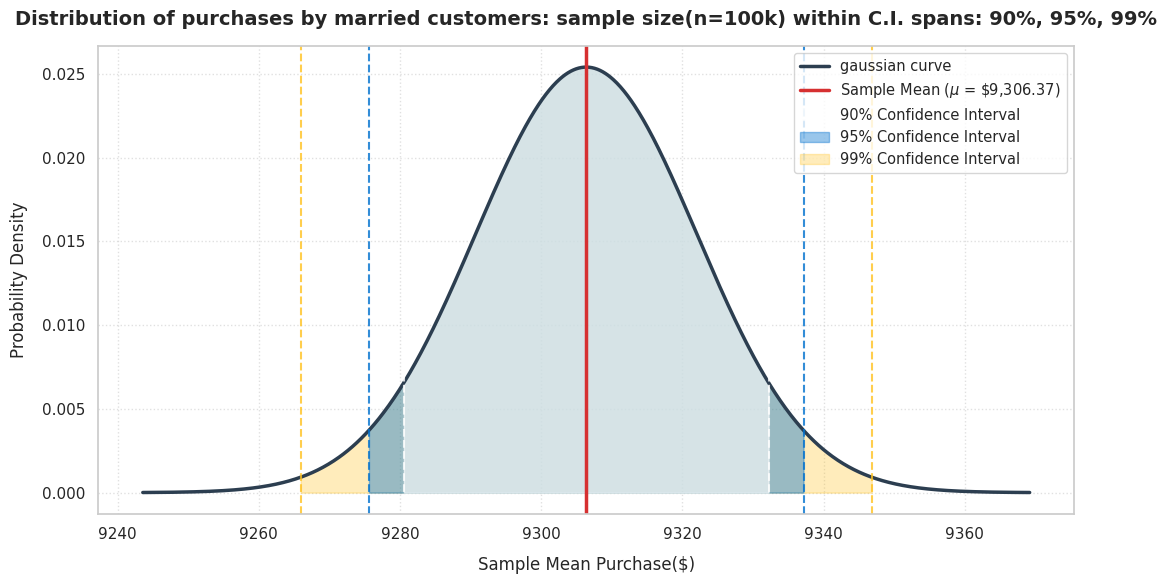

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Marital_Status'] == 1)]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Marital_Status = 1. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by married customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [300000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for ms in [1]:

        ms_pop = walmart[walmart['Marital_Status'] == ms]['Purchase']

        sample = ms_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Marital_Status': ms,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)  Marital_Status Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000               1              90%      9323.62          9.0796      9308.69      9338.56           29.87
         300000               1              95%      9323.62          9.0796      9305.83      9341.42           35.59
         300000               1              99%      9323.62          9.0796      9300.24      9347.01           46.77


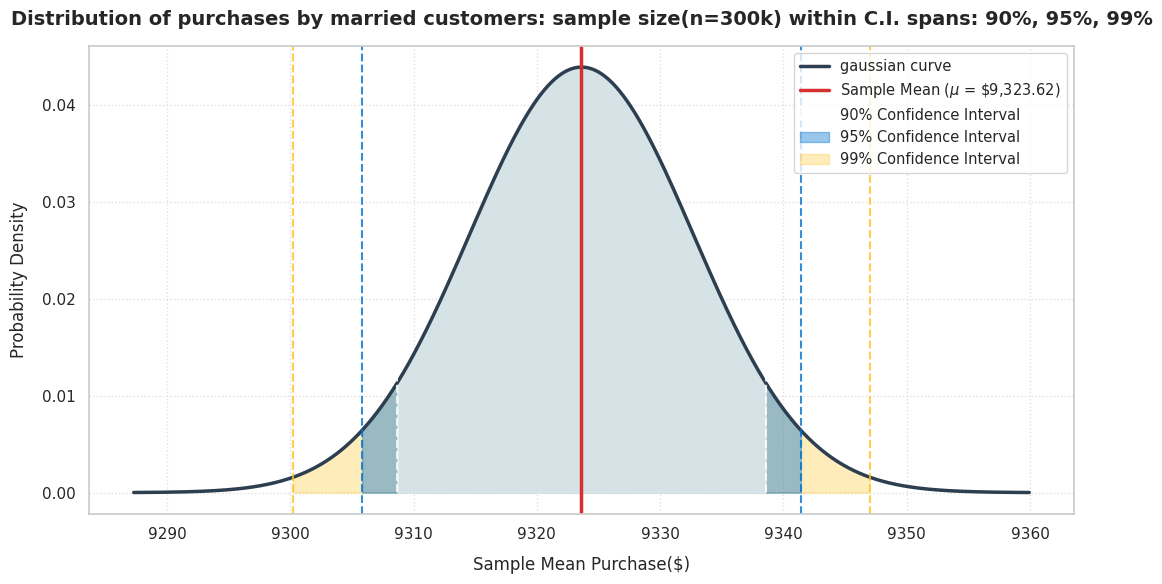

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Marital_Status'] == 1)]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Marital_Status = 1. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by married customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for ms in [1]:

        ms_pop = walmart[walmart['Marital_Status'] == ms]['Purchase']

        sample = ms_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Marital_Status': ms,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)  Marital_Status Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000               1              90%      9323.49          7.0289      9311.93      9335.06           23.12
         500000               1              95%      9323.49          7.0289      9309.72      9337.27           27.55
         500000               1              99%      9323.49          7.0289      9305.39      9341.60           36.21


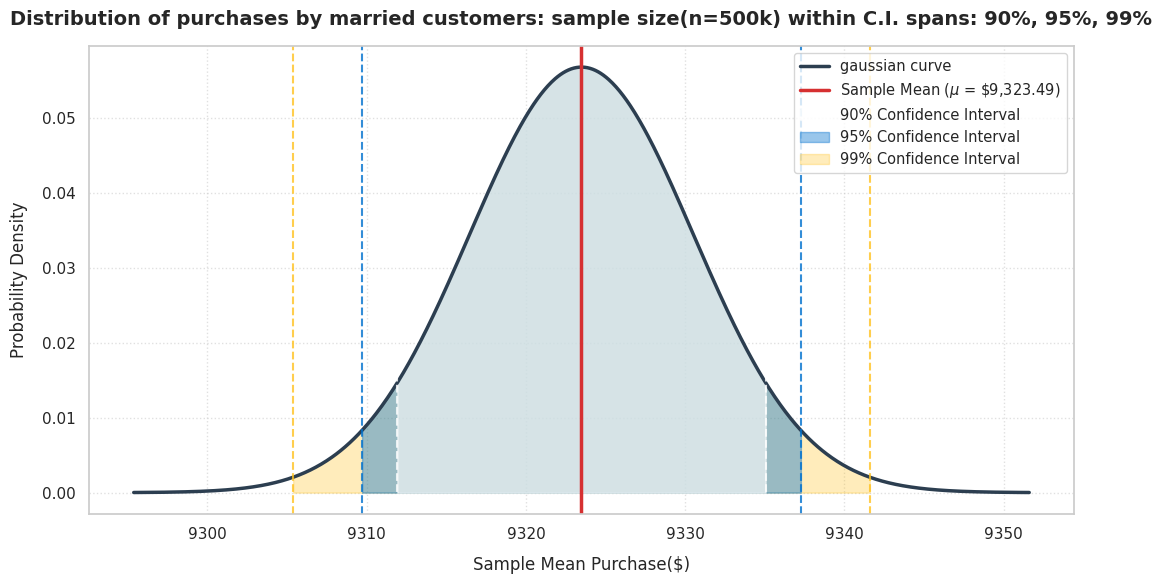

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Marital_Status'] == 1)]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Marital_Status = 1. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by married customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for ms in [0]:

        ms_pop = walmart[walmart['Marital_Status'] == ms]['Purchase']

        sample = ms_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Marital_Status': ms,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)  Marital_Status Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000               0              90%      9313.52          15.774      9287.58      9339.47           51.89
         100000               0              95%      9313.52          15.774      9282.61      9344.44           61.83
         100000               0              99%      9313.52          15.774      9272.89      9354.15           81.26


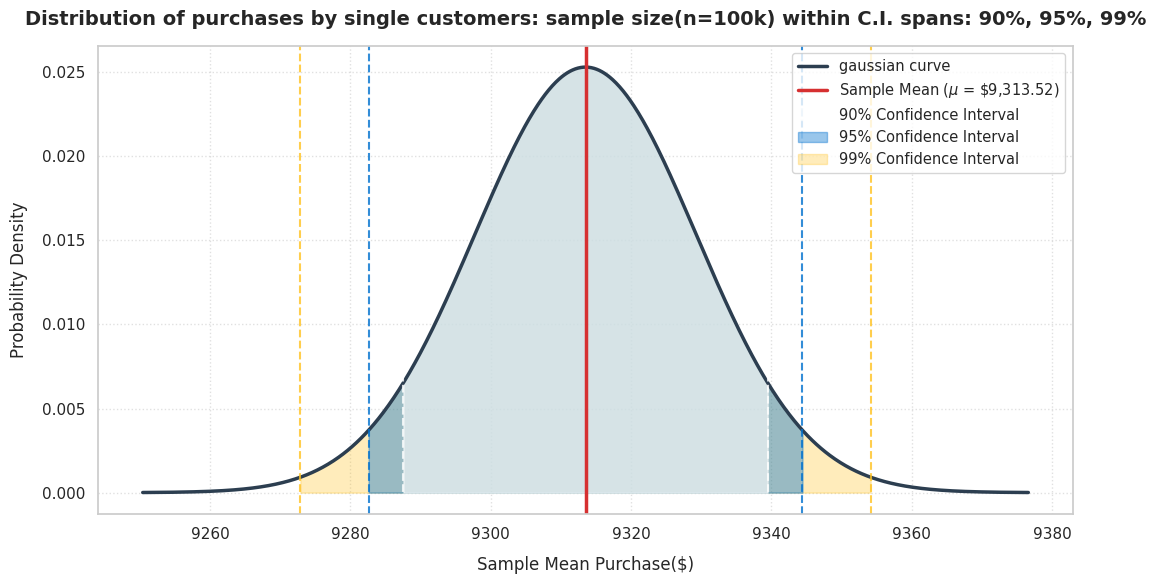

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Marital_Status'] == 0)]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Marital_Status = 0. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by single customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [300000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for ms in [0]:

        ms_pop = walmart[walmart['Marital_Status'] == ms]['Purchase']

        sample = ms_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Marital_Status': ms,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)  Marital_Status Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000               0              90%      9318.63          9.1051      9303.66      9333.61           29.95
         300000               0              95%      9318.63          9.1051      9300.79      9336.48           35.69
         300000               0              99%      9318.63          9.1051      9295.18      9342.09           46.91


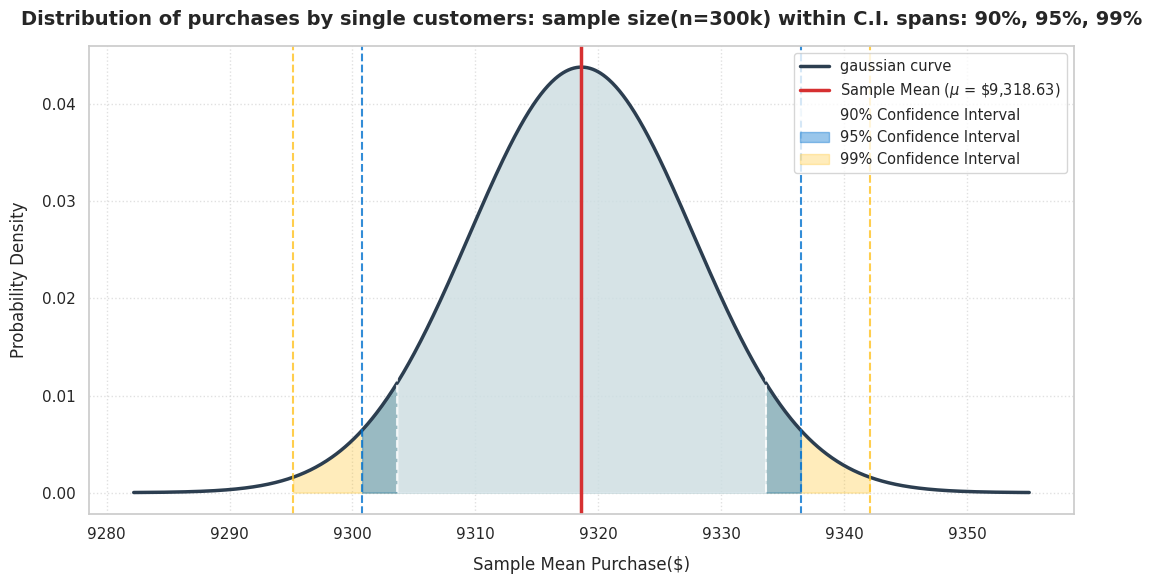

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Marital_Status'] == 0)]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Marital_Status = 0. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by single customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for ms in [0]:

        ms_pop = walmart[walmart['Marital_Status'] == ms]['Purchase']

        sample = ms_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Marital_Status': ms,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)  Marital_Status Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000               0              90%      9316.67          7.0523      9305.07      9328.27           23.20
         500000               0              95%      9316.67          7.0523      9302.85      9330.50           27.64
         500000               0              99%      9316.67          7.0523      9298.51      9334.84           36.33


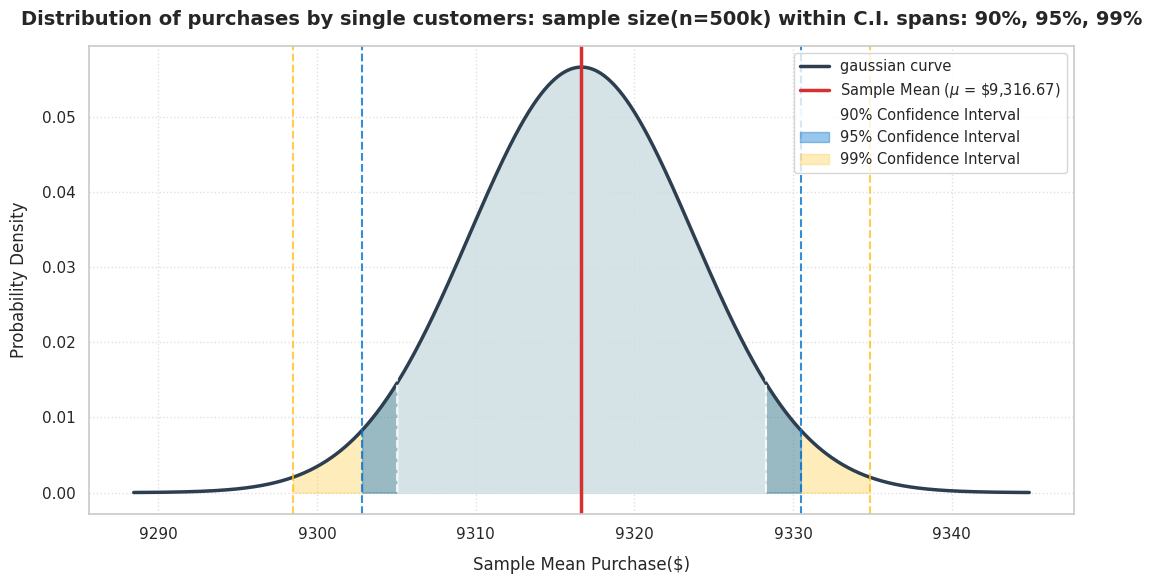

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Marital_Status'] == 0)]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Marital_Status = 0. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of purchases by single customers: sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

**Using the sample of married and single customers you will calculate the interval within which the average spending of 50 million married and single customers may lie.**

**Let's check if the confidence intervals of average married and single spends are overlapping or not overlapping.**

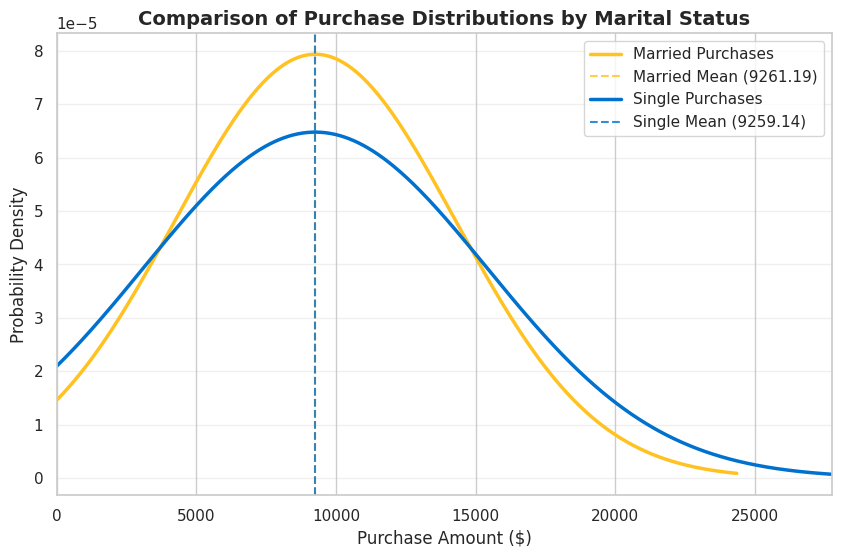

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(10, 6))

# ---- Curve 1: Married Customers ----
mu1, sigma1 = 9261.19, 5027.53
x1 = np.linspace(0, mu1 + 3*sigma1, 1000)
plt.plot(x1, stats.norm.pdf(x1, mu1, sigma1), label='Married Purchases', color='#FFC220', lw=2.5)
plt.axvline(mu1, color='#FFC220', linestyle='--', alpha=0.8, lw=1.5, label=f'Married Mean ({mu1:.2f})')

# ---- Curve 2: Single Customers ----
mu2, sigma2 = 9259.14, 6158.90
x2 = np.linspace(0, mu2 + 3*sigma2, 1000)
plt.plot(x2, stats.norm.pdf(x2, mu2, sigma2), label='Single Purchases', color='#0071CE', lw=2.5)
plt.axvline(mu2, color='#0071CE', linestyle='--', alpha=0.8, lw=1.5, label=f'Single Mean ({mu2:.2f})')

plt.title('Comparison of Purchase Distributions by Marital Status', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Amount ($)')
plt.ylabel('Probability Density')
plt.xlim(0, max(x1.max(), x2.max()))
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

---

# **Conclusion: marital status based analysis**

---
* **Total customers : 550k**
  * **324731 (single)**
  * **225337 (married)**


* **Unique customers : 5891**
  * **3417 (single)**
  * **2474 (Married)**


* **The average number of purchases per customer : 93**
  * **married : 91.08**
  * **single : 95.03**


* **59% single customers contribute to 58% of the total purchases.**
* **41% married customers contributes to 42% of the total purchases.**


* **Average purchase amount per transaction by Marital status**
  * **Married customers: 9261.17**
  * **Single customers: 9265.91**


* **95% confidence interval for married purchases: 9240 to 9281**
* **95% confidence interval for single purchases: 9248 to 9283**

* **The Confidence Intervals overlap heavily. In fact, they are almost entirely superimposed on each other.**

**Single Customers Have Higher Variance**

```
The blue curve for single purchases will be slightly shorter and wider.
This indicates that single customers are more unpredictable—
they have a wider spread of spending, likely making both very small purchases and highly expensive purchases.

```

**Married Customers are More Consistent**

```
The yellow curve for married purchases will be slightly taller and narrower.
Their spending behavior is more tightly clustered around the 9,261 average.

```
**Unified Marketing Strategy:**

```
From a business standpoint, you don’t need to differentiate pricing tiers or promotional discount values based on marital
status. A single campaign baseline works for both because their average purchasing power is identical.

```

**Risk/Inventory Planning:**
```
Because single buyers have a higher variance, inventory planning for items targeted heavily at single demographics requires
a larger buffer to account for the wider swing in demand/spending habits.

```

#**Marital status, much like gender, is an incredibly weak predictor of individual purchase amounts.**

---

# **Analysis based on age groups**

---

In [ ]:
walmart['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [ ]:
customer_distribution_by_age = walmart['User_ID'].groupby(walmart['Age']).count().reset_index()
total_0_17_customers = customer_distribution_by_age[customer_distribution_by_age['Age']==0-17]
total_18_25_customers = customer_distribution_by_age[customer_distribution_by_age['Age']==18-25]
total_26_35_customers = customer_distribution_by_age[customer_distribution_by_age['Age']==26_35]
total_36_45_customers = customer_distribution_by_age[customer_distribution_by_age['Age']==36_45]
total_46_50_customers = customer_distribution_by_age[customer_distribution_by_age['Age']==46_50]
total_51_55_customers = customer_distribution_by_age[customer_distribution_by_age['Age']==51_55]
total_55_customers = customer_distribution_by_age[customer_distribution_by_age['Age']== '55+']

In [ ]:
customer_distribution_by_age

,Age,User_ID
0,0-17,13519
1,18-25,89166
2,26-35,194886
3,36-45,97920
4,46-50,40357
5,51-55,34258
6,55+,19075


In [ ]:
unique_customers = walmart['User_ID'].groupby(walmart['Age']).nunique().reset_index('Age')

unique_0_17_customers = unique_customers[unique_customers['Age']==0-17]
unique_18_25_customers = unique_customers[unique_customers['Age']==18-25]
unique_26_35_customers = unique_customers[unique_customers['Age']==26_35]
unique_36_45_customers = unique_customers[unique_customers['Age']==36_45]
unique_46_50_customers = unique_customers[unique_customers['Age']==46_50]
unique_51_55_customers = unique_customers[unique_customers['Age']==51_55]
unique_55_customers = unique_customers[unique_customers['Age']== '55+']


In [ ]:
unique_customers

,Age,User_ID
0,0-17,218
1,18-25,1069
2,26-35,2053
3,36-45,1167
4,46-50,531
5,51-55,481
6,55+,372


In [ ]:
total_0_17_customers = customer_distribution_by_age[customer_distribution_by_age['Age']=='0-17']
unique_0_17_customers = unique_customers[unique_customers['Age']=='0-17']
avg_pur_amt_0_17_customers = (total_0_17_customers['User_ID'].iloc[0] / unique_0_17_customers['User_ID'].iloc[0]).round(2)
print(f"Average number of purchases of customers in age group 0-17 is {avg_pur_amt_0_17_customers}")

Average number of purchases of customers in age group 0-17 is 62.01


**Average number of purchases of customers in age group 0-17 is 69.28**

In [ ]:
total_18_25_customers = customer_distribution_by_age[customer_distribution_by_age['Age']=='18-25']
unique_18_25_customers = unique_customers[unique_customers['Age']=='18-25']
avg_pur_amt_18_25_customers = (total_18_25_customers['User_ID'].iloc[0] / unique_18_25_customers['User_ID'].iloc[0]).round(2)
print(f"Average number of purchase of customers in age group 18-25 is {avg_pur_amt_18_25_customers}")

Average number of purchase of customers in age group 18-25 is 83.41


**Average number of purchases of customers in age group 18-25 is 93.23**

In [ ]:
total_26_35_customers = customer_distribution_by_age[customer_distribution_by_age['Age']=='26-35']
unique_26_35_customers = unique_customers[unique_customers['Age']=='26-35']
avg_pur_amt_26_35_customers = (total_26_35_customers['User_ID'].iloc[0] / unique_26_35_customers['User_ID'].iloc[0]).round(2)
print(f"Average number of purchase of customers in age group 26-25 is {avg_pur_amt_26_35_customers}")

Average number of purchase of customers in age group 26-25 is 94.93


**Average number of purchase of customers in age group 26-25 is 106.96**

In [ ]:

total_36_45_customers = customer_distribution_by_age[customer_distribution_by_age['Age']=='36-45']
unique_36_45_customers = unique_customers[unique_customers['Age']=='36-45']
avg_pur_amt_36_45_customers = (total_36_45_customers['User_ID'].iloc[0] / unique_36_45_customers['User_ID'].iloc[0]).round(2)
print(f"Average number of purchase of customers in age group 36-45 is {avg_pur_amt_36_45_customers}")

Average number of purchase of customers in age group 36-45 is 83.91


**Average number of purchase of customers in age group 36-45 is 94.27**

In [ ]:
total_46_50_customers = customer_distribution_by_age[customer_distribution_by_age['Age']=='46-50']
unique_46_50_customers = unique_customers[unique_customers['Age']=='46-50']
avg_pur_amt_46_50_customers = (total_46_50_customers['User_ID'].iloc[0] / unique_46_50_customers['User_ID'].iloc[0]).round(2)
print(f"Average number of purchase of customers in age group 46-50 is {avg_pur_amt_46_50_customers}")

Average number of purchase of customers in age group 46-50 is 76.0


**Average number of purchase of customers in age group 46-50 is 86.07**

In [ ]:
total_51_55_customers = customer_distribution_by_age[customer_distribution_by_age['Age']=='51-55']
unique_51_55_customers = unique_customers[unique_customers['Age']=='51-55']
avg_pur_amt_51_55_customers = (total_51_55_customers['User_ID'].iloc[0] / unique_51_55_customers['User_ID'].iloc[0]).round(2)
print(f"Average number of purchase of customers in age group 51-55 is {avg_pur_amt_51_55_customers}")

Average number of purchase of customers in age group 51-55 is 71.22


**Average number of purchase of customers in age group 51-55 is 80.04**

In [ ]:
total_55_customers = customer_distribution_by_age[customer_distribution_by_age['Age']=='55+']
unique_55_customers = unique_customers[unique_customers['Age']=='55+']
avg_pur_amt_55_customers = (total_55_customers['User_ID'].iloc[0] / unique_55_customers['User_ID'].iloc[0]).round(2)
print(f"Average number of purchase of customers in age group above 55 is {avg_pur_amt_55_customers}")

Average number of purchase of customers in age group above 55 is 51.28


**Average number of purchase of customers in age group above 55 is 57.81**

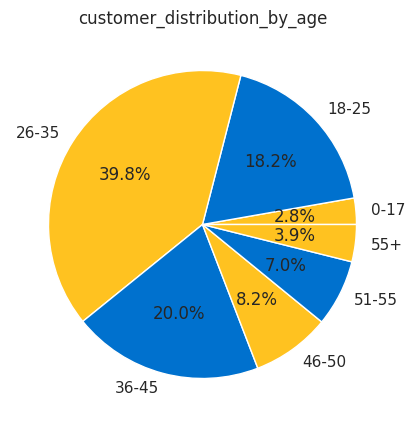

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(x=customer_distribution_by_age['User_ID'], labels=customer_distribution_by_age['Age'], colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('customer_distribution_by_age')
plt.show()

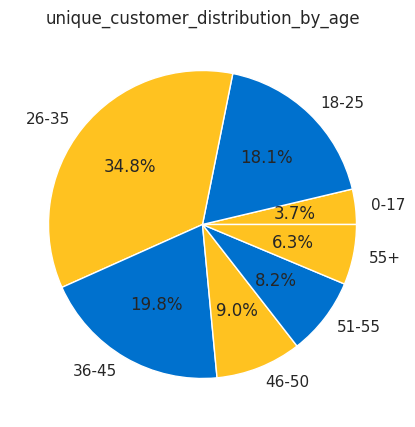

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(x=unique_customers['User_ID'], labels=unique_customers['Age'], colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('unique_customer_distribution_by_age')
plt.show()

**Customers between the ages 18-45 contributes to 72.7%  unique customers**

  * **18-25 year olds = 18.1% customers**

  * **26-35 year olds = 34.8% customers**

  * **36-45 year olds = 19.8% customers**

**Customers between the ages 18-45 contributes to 80% total customers**

* **18.1% 18-25 year olds = 18.1% of total customers**

* **34.8% 26-35 year olds = 39.9% of total customers**

* **19.8% 36-45 year olds = 20% of total customers**

In [ ]:
avg_purcahse_0_17_customers = (walmart[walmart['Age']=='0-17']['Purchase'].mean()).round(2)
print(f"Average purchase amount for customers in age group 0-17 is {avg_purcahse_0_17_customers}")

Average purchase amount for customers in age group 0-17 is 9035.82


**Average purchase amount for customers in age group 0-17 is 8933.46**

In [ ]:
avg_purchase_18_25_customers = (walmart[walmart['Age']=='18-25']['Purchase'].mean()).round(2)
print(f"Average purchase amount for customers in age group 18-25 is {avg_purchase_18_25_customers}")

Average purchase amount for customers in age group 18-25 is 9236.56


**Average purchase amount for customers in age group 18-25 is 9169.66**

In [ ]:
avg_purchase_26_35_customers = (walmart[walmart['Age']=='26-35']['Purchase'].mean()).round(2)
print(f"Average purchase amount for customers in age group 26-35 is {avg_purchase_26_35_customers}")

Average purchase amount for customers in age group 26-35 is 9307.25


**Average purchase amount for customers in age group 26-35 is 9252.69**

In [ ]:
avg_purchase_36_45_customers = (walmart[walmart['Age']=='36-45']['Purchase'].mean()).round(2)
print(f"Average purchase amount for customers in age group 36-45 is {avg_purchase_36_45_customers}")

Average purchase amount for customers in age group 36-45 is 9391.13


**Average purchase amount for customers in age group 36-45 is 9331.35**

In [ ]:
avg_purchase_46_50_customers = (walmart[walmart['Age']=='46-50']['Purchase'].mean()).round(2)
print(f"Average purchase amount for customers in age group 46-50 is {avg_purchase_46_50_customers}")

Average purchase amount for customers in age group 46-50 is 9278.49


**Average purchase amount for customers in age group 46-50 is 9208.63**

In [ ]:
avg_purchase_51_55_customers = (walmart[walmart['Age']=='51-55']['Purchase'].mean()).round(2)
print(f"Average purchase amount for customers in age group 51-55 is {avg_purchase_51_55_customers}")

Average purchase amount for customers in age group 51-55 is 9620.95


**Average purchase amount for customers in age group 51-55 is 9534.81**

In [ ]:
avg_purchase_55_customers = (walmart[walmart['Age']=='55+']['Purchase'].mean()).round(2)
print(f"Average purchase amount for customers in age group above 55 is {avg_purchase_55_customers}")

Average purchase amount for customers in age group above 55 is 9446.38


**Average purchase amount for customers in age group above 55 is 9336.28**

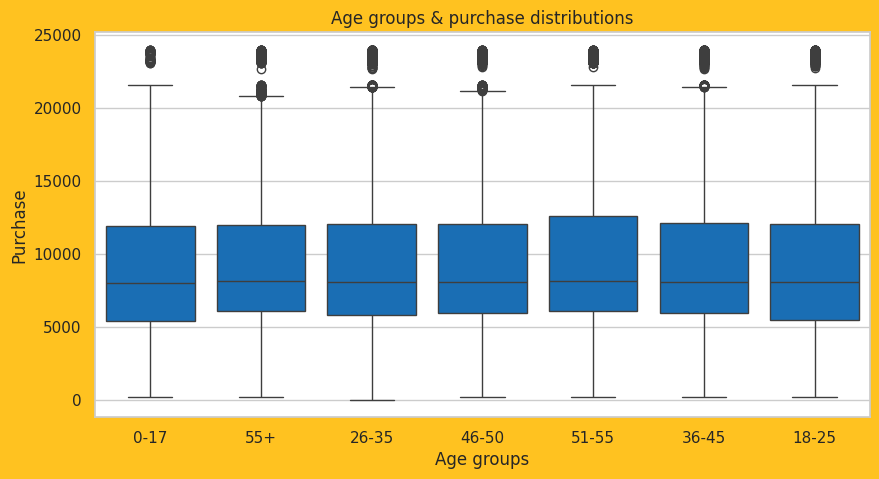

In [ ]:
plt.figure(figsize=(10,5), facecolor='#FFC220')
sns.boxplot(x=walmart['Age'], y=walmart['Purchase'], color='#0071CE')
plt.xlabel('Age groups')
plt.ylabel('Purchase')
plt.title('Age groups & purchase distributions')
plt.show()

**Confidence Interval for Average Purchase by Age**

Now, let's calculate the 95% confidence interval for the average purchase amount for customers of all age groups. This will give us a range within which the true population mean is likely to fall.

```
Let's seperate the dataset based on age groups
```

In [ ]:
customers_0_17 = walmart[walmart['Age'] == '0-17']
customers_0_17.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
85,1000019,P00112542,M,0-17,10,A,3,0,1,7746


In [ ]:
import scipy.stats as st

customers_0_17_mean = customers_0_17['Purchase'].mean()
customers_0_17_std = customers_0_17['Purchase'].std()
customers_0_17_n = len(customers_0_17)
customers_0_17_ci = st.norm.interval(confidence = 0.95, loc = customers_0_17_mean, scale = customers_0_17_std/np.sqrt(customers_0_17_n))

print(f"95% confidence interval for customers 0-17 year olds purchase: {customers_0_17_ci}")

95% confidence interval for customers 0-17 year olds purchase: (np.float64(8950.33638890357), np.float64(9121.307223789676))


**95% confidence interval for customers 0-17 year olds purchase: 8851.94 to 9014.98**

In [ ]:
customers_18_25 = walmart[walmart['Age'] == '18-25']
customers_18_25.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
70,1000018,P00366542,F,18-25,3,B,3,0,5,1780
71,1000018,P00190742,F,18-25,3,B,3,0,3,10754
72,1000018,P00151842,F,18-25,3,B,3,0,4,2802
73,1000018,P00112642,F,18-25,3,B,3,0,1,19473
74,1000018,P00118442,F,18-25,3,B,3,0,1,19672


In [ ]:
import scipy.stats as st

customers_18_25_mean = customers_18_25['Purchase'].mean()
customers_18_25_std = customers_18_25['Purchase'].std()
customers_18_25_n = len(customers_18_25)
customers_18_25_ci = st.norm.interval(confidence = 0.95, loc = customers_18_25_mean, scale = customers_18_25_std/np.sqrt(customers_18_25_n))

print(f"95% confidence interval for customers 18-25 year olds purchase: {customers_18_25_ci}")

95% confidence interval for customers 18-25 year olds purchase: (np.float64(9203.74729423517), np.float64(9269.373760875522))


**95% confidence interval for customers 18-25 year olds purchase: 9138.40 to 9200.91**

In [ ]:
customers_26_35 = walmart[walmart['Age'] == '26-35']
customers_26_35.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
9,1000005,P00274942,M,26-35,20,A,1,1,8,7871
10,1000005,P00251242,M,26-35,20,A,1,1,5,5254
11,1000005,P00014542,M,26-35,20,A,1,1,8,3957
12,1000005,P00031342,M,26-35,20,A,1,1,8,6073


In [ ]:
import scipy.stats as st

customers_26_35_mean = customers_26_35['Purchase'].mean()
customers_26_35_std = customers_26_35['Purchase'].std()
customers_26_35_n = len(customers_26_35)
customers_26_35_ci = st.norm.interval(confidence = 0.95, loc = customers_26_35_mean, scale = customers_26_35_std/np.sqrt(customers_26_35_n))

print(f"95% confidence interval for customers 26-35 year olds purchase: {customers_26_35_ci}")

95% confidence interval for customers 26-35 year olds purchase: (np.float64(9285.180300044294), np.float64(9329.314892016706))


**95% confidence interval for customers 26-35 year olds purchase: 9231.73 to 9273.64**

In [ ]:
customers_36_45 = walmart[walmart['Age'] == '36-45']
customers_36_45.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
18,1000007,P00036842,M,36-45,1,B,1,1,1,11788
29,1000010,P00085942,F,36-45,1,B,4+,1,2,16352
30,1000010,P00118742,F,36-45,1,B,4+,1,5,8886
31,1000010,P00297942,F,36-45,1,B,4+,1,8,5875
32,1000010,P00266842,F,36-45,1,B,4+,1,5,8854


In [ ]:
import scipy.stats as st

customers_36_45_mean = customers_36_45['Purchase'].mean()
customers_36_45_std = customers_36_45['Purchase'].std()
customers_36_45_n = len(customers_36_45)
customers_36_45_ci = st.norm.interval(confidence = 0.95, loc = customers_36_45_mean, scale = customers_36_45_std/np.sqrt(customers_36_45_n))

print(f"95% confidence interval for customers 36-45 year olds purchase: {customers_36_45_ci}")

95% confidence interval for customers 36-45 year olds purchase: (np.float64(9359.953612984556), np.float64(9422.308866590605))


**95% confidence interval for customers 36-45 year olds purchase: 9301.66 to 9361.03**

In [ ]:
customers_46_50 = walmart[walmart['Age'] == '46-50']
customers_46_50.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686
52,1000013,P00129542,M,46-50,1,C,3,1,8,5839
53,1000013,P00140742,M,46-50,1,C,3,1,1,15912


In [ ]:
import scipy.stats as st

customers_46_50_mean = customers_46_50['Purchase'].mean()
customers_46_50_std = customers_46_50['Purchase'].std()
customers_46_50_n = len(customers_46_50)
customers_46_50_ci = st.norm.interval(confidence = 0.95, loc = customers_46_50_mean, scale = customers_46_50_std/np.sqrt(customers_46_50_n))

print(f"95% confidence interval for customers 46-50 year olds purchase: {customers_46_50_ci}")

95% confidence interval for customers 46-50 year olds purchase: (np.float64(9230.576838424267), np.float64(9326.397069447974))


**95% confidence interval for customers 46-50 year olds purchase: 9163.08 to 9254.16**

In [ ]:
customers_51_55 = walmart[walmart['Age'] == '51-55']
customers_51_55.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
14,1000006,P00231342,F,51-55,9,A,1,0,5,5378
15,1000006,P00190242,F,51-55,9,A,1,0,4,2079
16,1000006,P0096642,F,51-55,9,A,1,0,2,13055
17,1000006,P00058442,F,51-55,9,A,1,0,5,8851
67,1000017,P00019342,M,51-55,1,C,0,0,1,15872


In [ ]:
import scipy.stats as st

customers_51_55_mean = customers_51_55['Purchase'].mean()
customers_51_55_std = customers_51_55['Purchase'].std()
customers_51_55_n = len(customers_51_55)
customers_51_55_ci = st.norm.interval(confidence = 0.95, loc = customers_51_55_mean, scale = customers_51_55_std/np.sqrt(customers_51_55_n))

print(f"95% confidence interval for customers 51-55 year olds purchase: {customers_51_55_ci}")

95% confidence interval for customers 51-55 year olds purchase: (np.float64(9567.687054991144), np.float64(9674.20850225096))


**95% confidence interval for customers 51-55 year olds purchase: 9483.99 to 9585.62**


In [ ]:
customers_55 = walmart[walmart['Age'] == '55+']
customers_55.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
159,1000031,P00117442,M,55+,7,C,2,0,5,8596
160,1000031,P00322042,M,55+,7,C,2,0,5,5248
161,1000031,P00216342,M,55+,7,C,2,0,3,10592
162,1000031,P00329342,M,55+,7,C,2,0,5,3482


In [ ]:
import scipy.stats as st

customers_55_mean = customers_55['Purchase'].mean()
customers_55_std = customers_55['Purchase'].std()
customers_55_n = len(customers_55)
customers_55_ci = st.norm.interval(confidence = 0.95, loc = customers_55_mean, scale = customers_55_std/np.sqrt(customers_55_n))

print(f"95% confidence interval for customers above 55 year olds purchase: {customers_55_ci}")

95% confidence interval for customers above 55 year olds purchase: (np.float64(9376.43143534903), np.float64(9516.326939487142))


**95% confidence interval for customers above 55 year olds purchase: 9269.29 to 9403.26**



Let's use the Central limit theorem to compute the Confidence Interval. we'll change the sample size to observe the distribution of the mean of the expenses by female and male customers.

The width of the interval is mostly decided by the business:Typically 90%, 95%, or 99%.

We'll play around with the width parameter and report the observations.

In [ ]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['0-17']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)  Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000 0-17              90%      9050.05          16.096      9023.58      9076.53           52.95
         100000 0-17              95%      9050.05          16.096      9018.50      9081.60           63.10
         100000 0-17              99%      9050.05          16.096      9008.59      9091.51           82.92


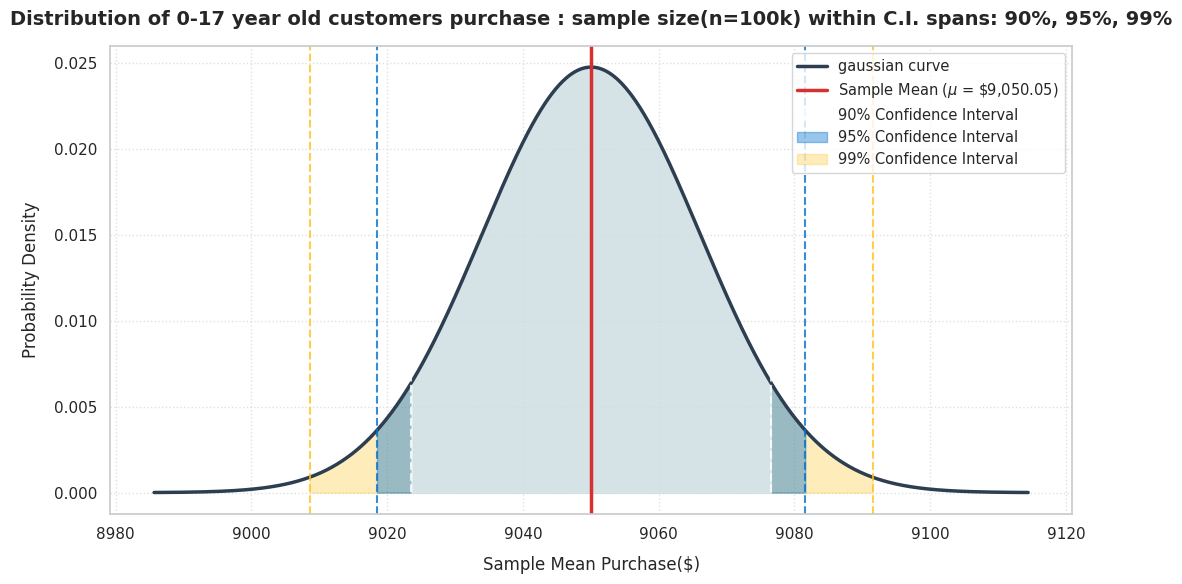

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '0-17')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '0-17'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 0-17 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [300000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['0-17']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)  Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000 0-17              90%      9024.37          9.2617      9009.14      9039.60           30.47
         300000 0-17              95%      9024.37          9.2617      9006.22      9042.52           36.31
         300000 0-17              99%      9024.37          9.2617      9000.51      9048.23           47.71


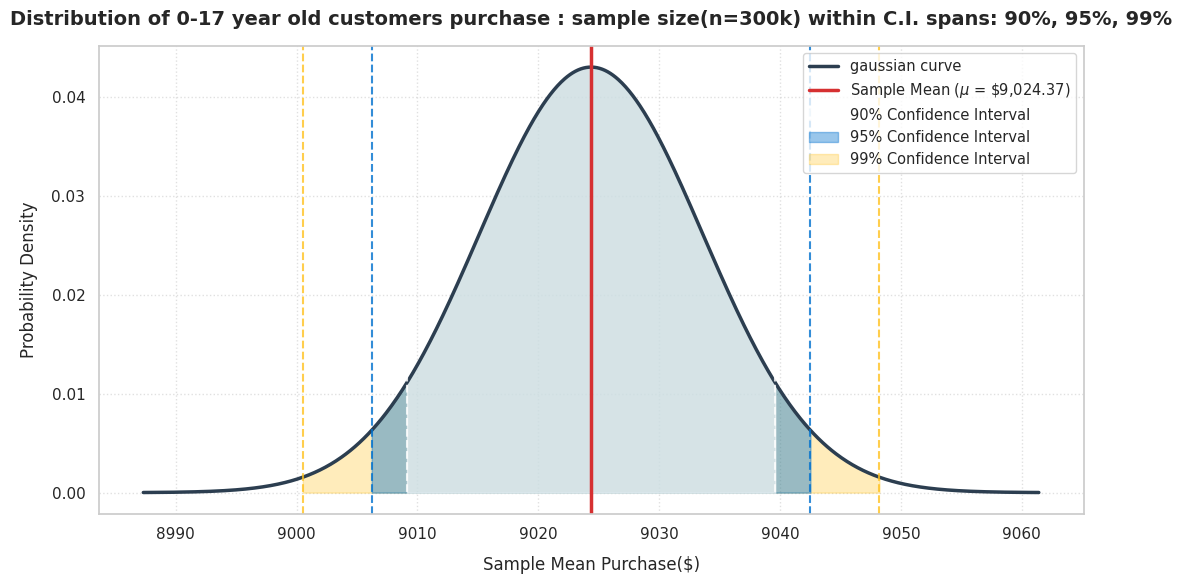

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '0-17')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '0-17'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 0-17 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['0-17']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)  Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000 0-17              90%       9034.2           7.168      9022.41      9045.99           23.58
         500000 0-17              95%       9034.2           7.168      9020.16      9048.25           28.10
         500000 0-17              99%       9034.2           7.168      9015.74      9052.67           36.93


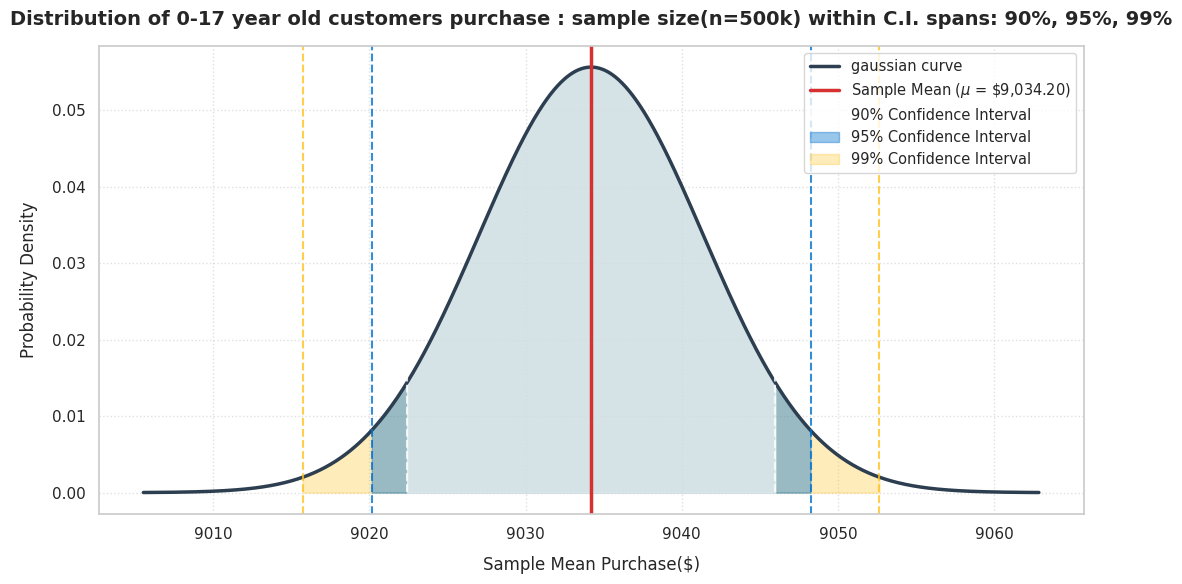

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '0-17')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '0-17'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 0-17 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['18-25']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000 18-25              90%      9231.53         15.7728      9205.59      9257.47           51.89
         100000 18-25              95%      9231.53         15.7728      9200.62      9262.44           61.83
         100000 18-25              99%      9231.53         15.7728      9190.90      9272.16           81.26


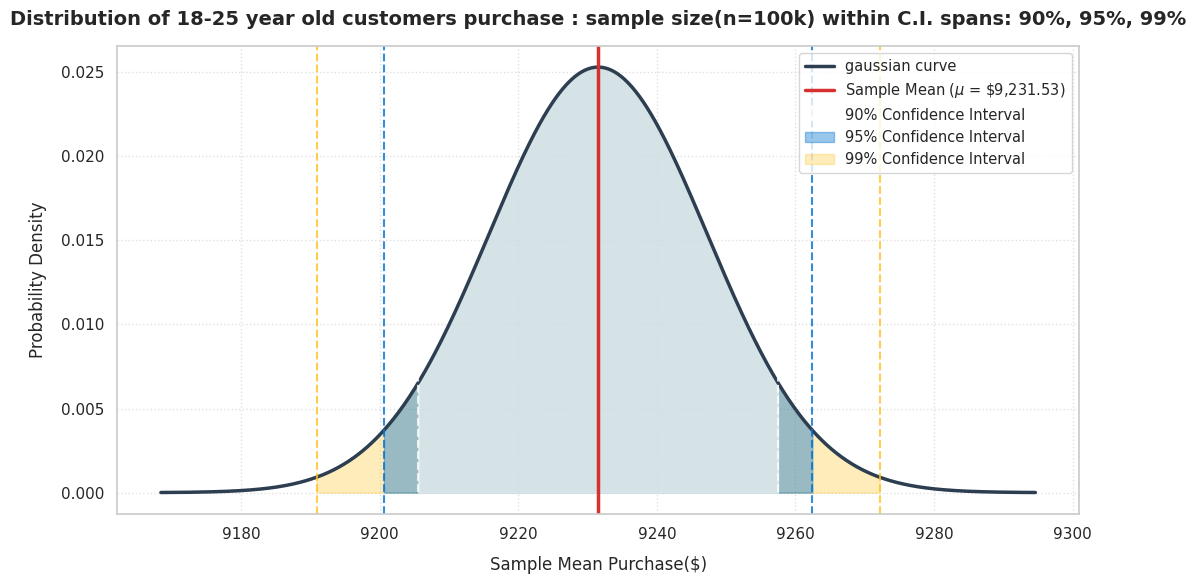

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '18-25')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '18-25'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 18-25 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [300000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['18-25']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000 18-25              90%      9234.39          9.1228      9219.38      9249.39           30.01
         300000 18-25              95%      9234.39          9.1228      9216.51      9252.27           35.76
         300000 18-25              99%      9234.39          9.1228      9210.89      9257.89           47.00


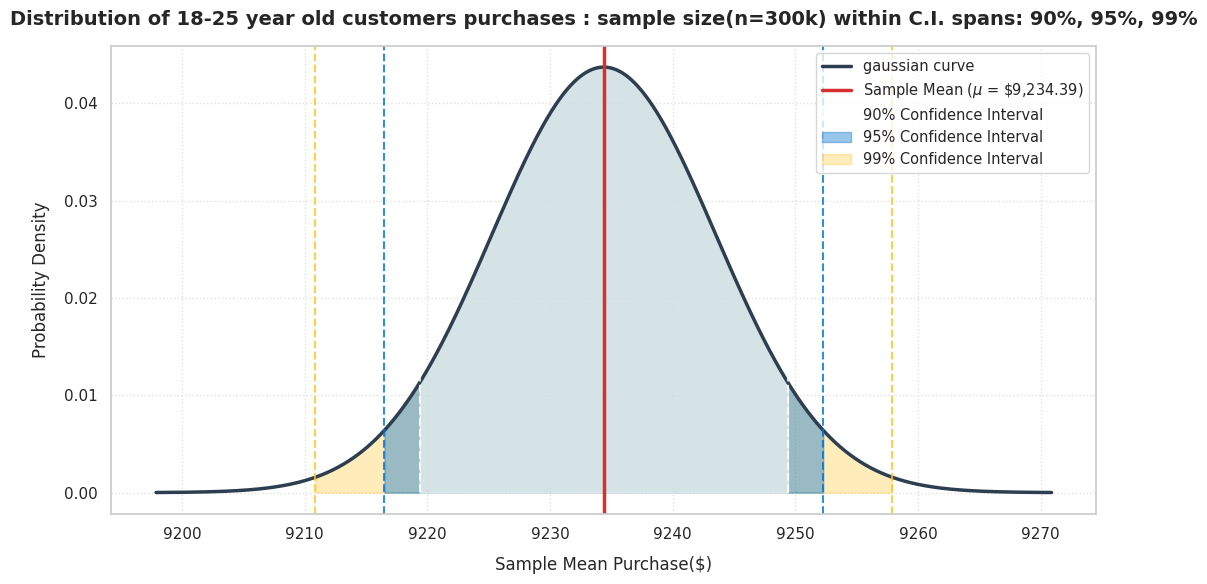

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '18-25')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '18-25'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 18-25 year old customers purchases : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['18-25']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000 18-25              90%      9239.44          7.0766      9227.80      9251.08           23.28
         500000 18-25              95%      9239.44          7.0766      9225.57      9253.31           27.74
         500000 18-25              99%      9239.44          7.0766      9221.21      9257.66           36.46


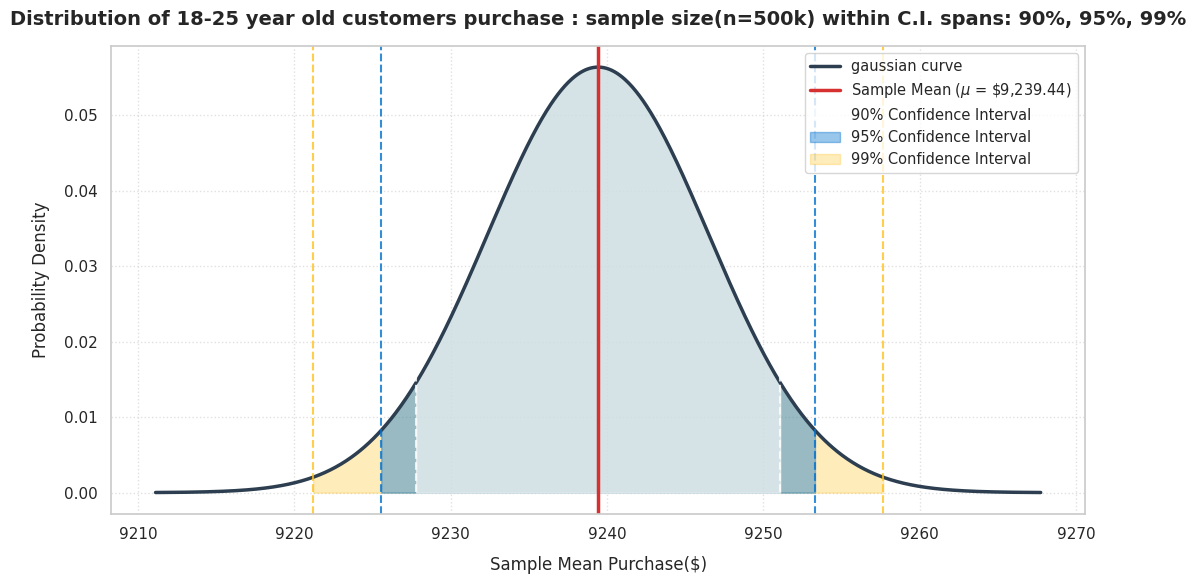

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '18-25')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '18-25'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 18-25 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['26-35']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000 26-35              90%      9302.25         15.6418      9276.52      9327.98           51.46
         100000 26-35              95%      9302.25         15.6418      9271.59      9332.91           61.31
         100000 26-35              99%      9302.25         15.6418      9261.96      9342.54           80.58


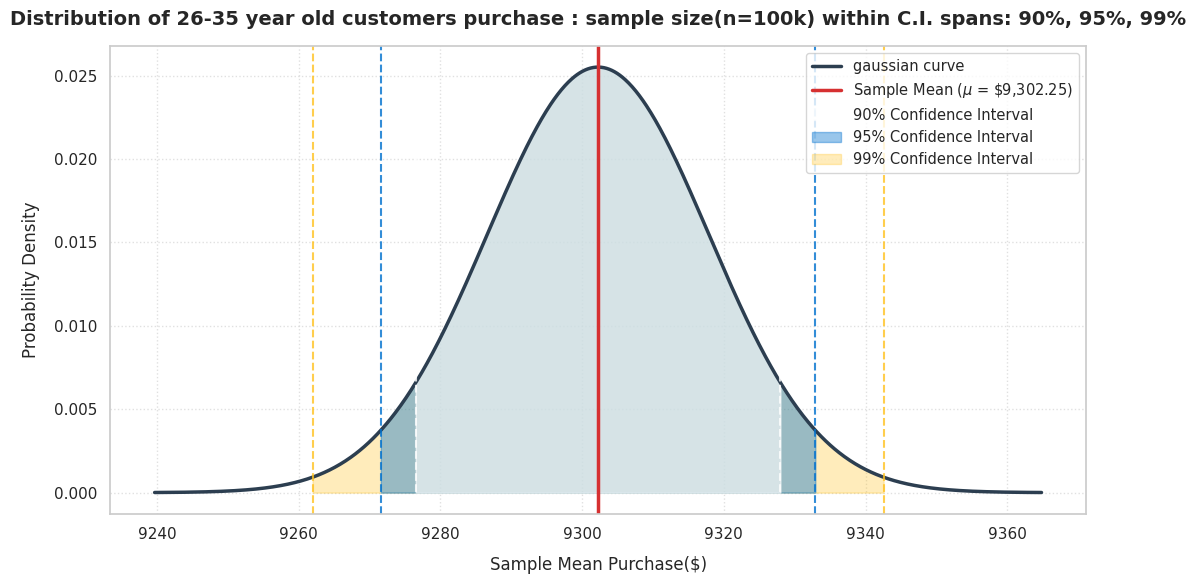

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '26-35')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '26-35'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 26-35 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [300000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['26-35']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000 26-35              90%      9320.13          9.0714      9305.21      9335.05           29.84
         300000 26-35              95%      9320.13          9.0714      9302.35      9337.91           35.56
         300000 26-35              99%      9320.13          9.0714      9296.76      9343.49           46.73


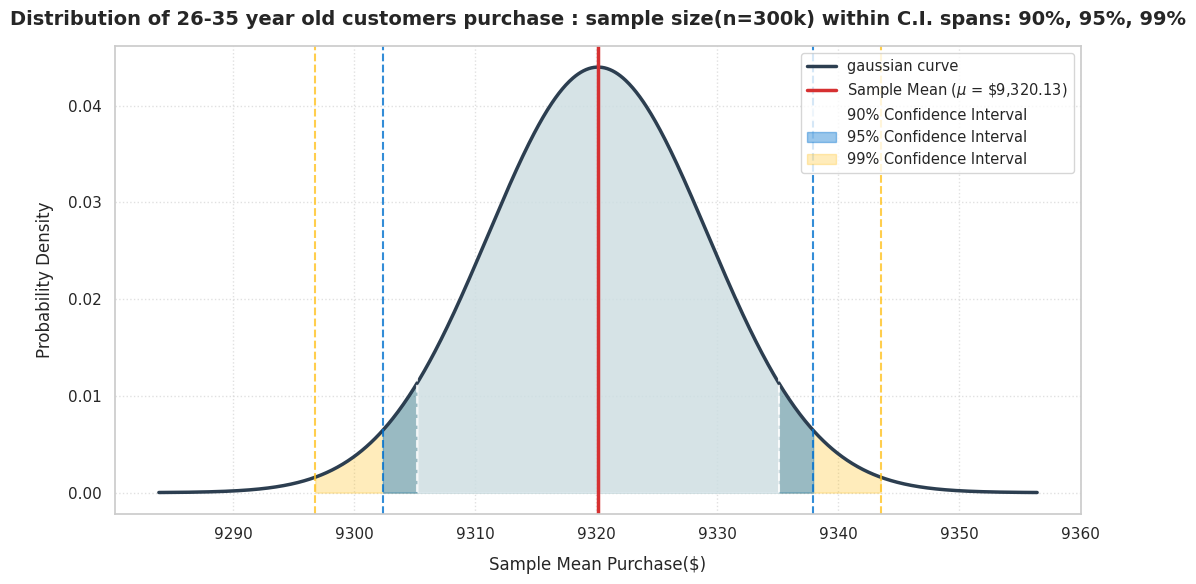

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '26-35')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '26-35'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 26-35 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['26-35']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000 26-35              90%      9315.96           7.025      9304.40      9327.51           23.11
         500000 26-35              95%      9315.96           7.025      9302.19      9329.73           27.54
         500000 26-35              99%      9315.96           7.025      9297.86      9334.05           36.19


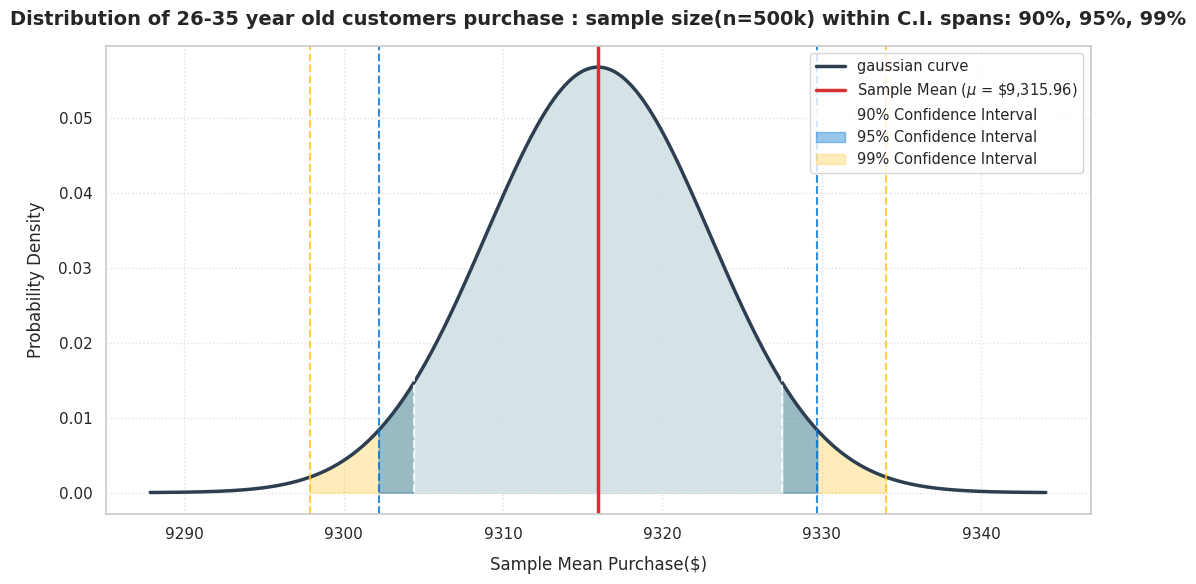

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '26-35')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '26-35'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 26-35 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['36-45']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000 36-45              90%       9347.1          15.677      9321.31      9372.89           51.57
         100000 36-45              95%       9347.1          15.677      9316.37      9377.83           61.45
         100000 36-45              99%       9347.1          15.677      9306.72      9387.48           80.76


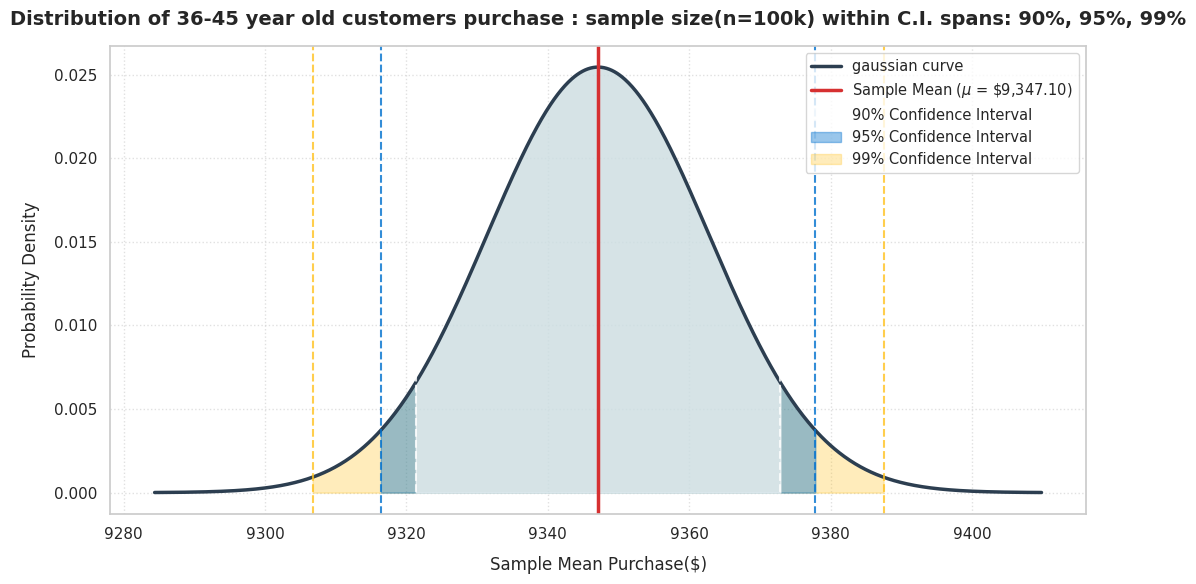

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '36-45')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '36-45'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 36-45 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [300000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['36-45']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000 36-45              90%      9387.04          9.0814      9372.10      9401.98           29.88
         300000 36-45              95%      9387.04          9.0814      9369.24      9404.84           35.60
         300000 36-45              99%      9387.04          9.0814      9363.65      9410.43           46.78


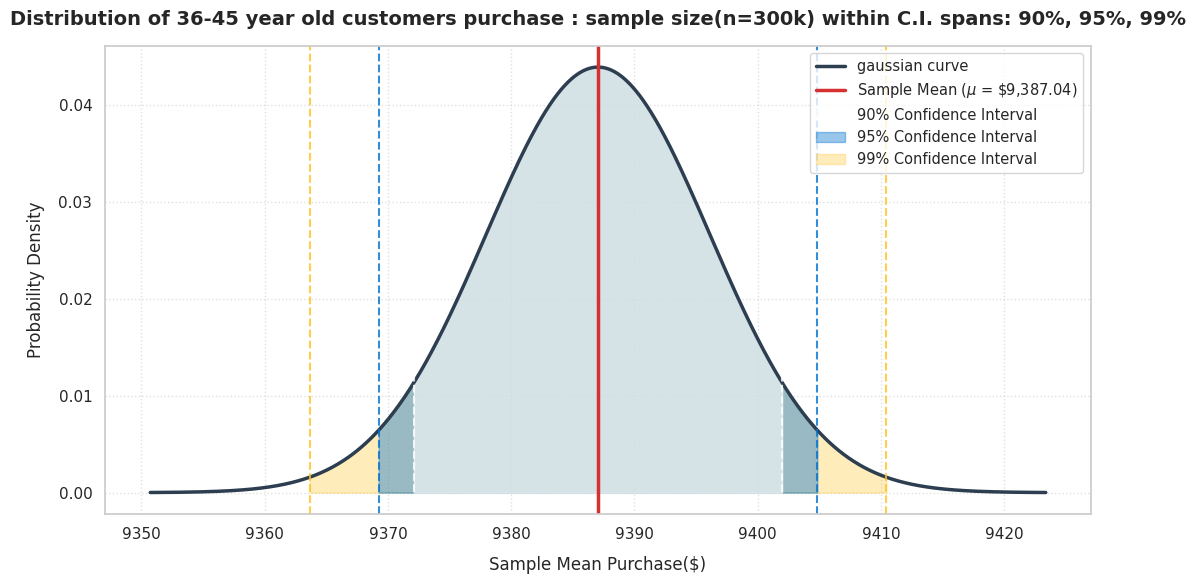

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '36-45')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '36-45'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 36-45 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['36-45']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000 36-45              90%      9388.27           7.039      9376.69      9399.85           23.16
         500000 36-45              95%      9388.27           7.039      9374.47      9402.07           27.59
         500000 36-45              99%      9388.27           7.039      9370.14      9406.40           36.26


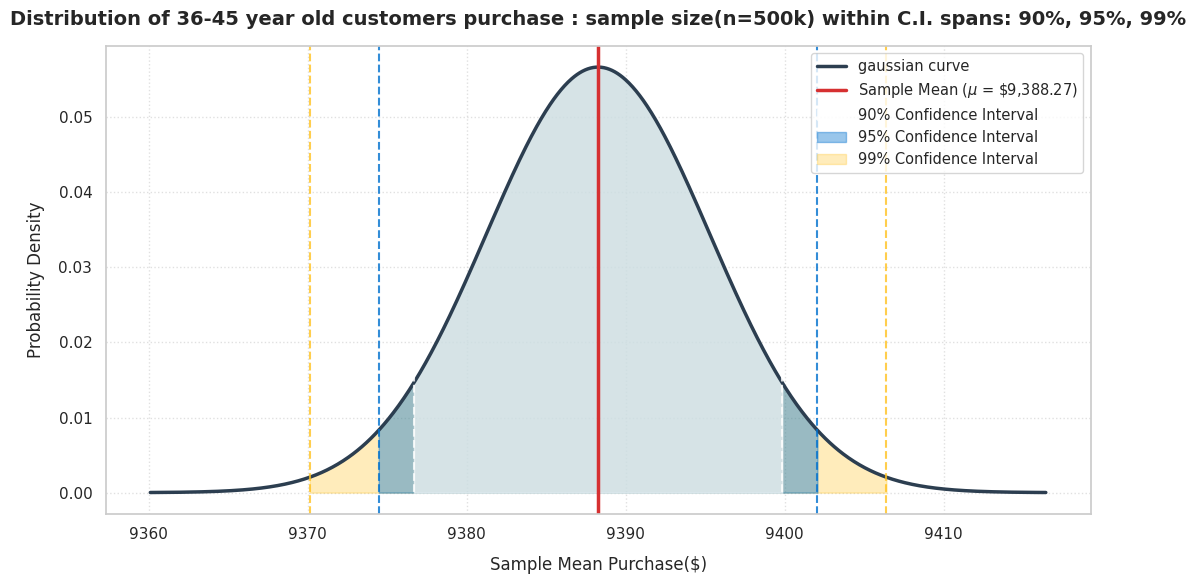

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '36-45')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '36-45'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 36-45 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['46-50']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000 46-50              90%      9248.53         15.4923      9223.05      9274.01           50.97
         100000 46-50              95%      9248.53         15.4923      9218.16      9278.89           60.73
         100000 46-50              99%      9248.53         15.4923      9208.62      9288.43           79.81


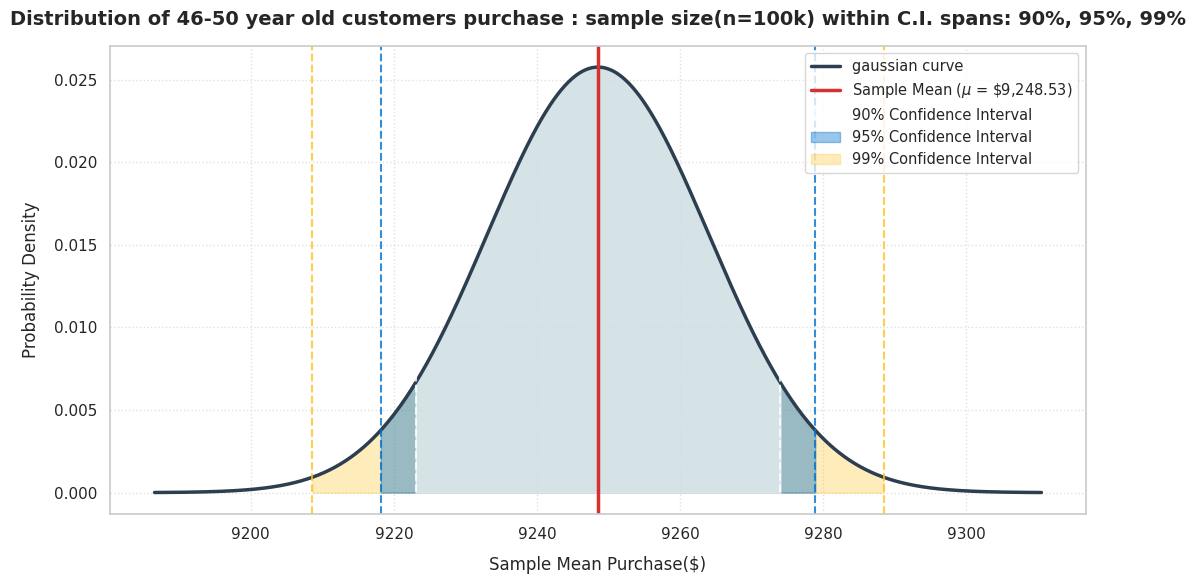

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '46-50')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '46-50'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 46-50 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [300000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['46-50']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000 46-50              90%      9281.16          8.9793      9266.39      9295.93           29.54
         300000 46-50              95%      9281.16          8.9793      9263.56      9298.76           35.20
         300000 46-50              99%      9281.16          8.9793      9258.03      9304.29           46.26


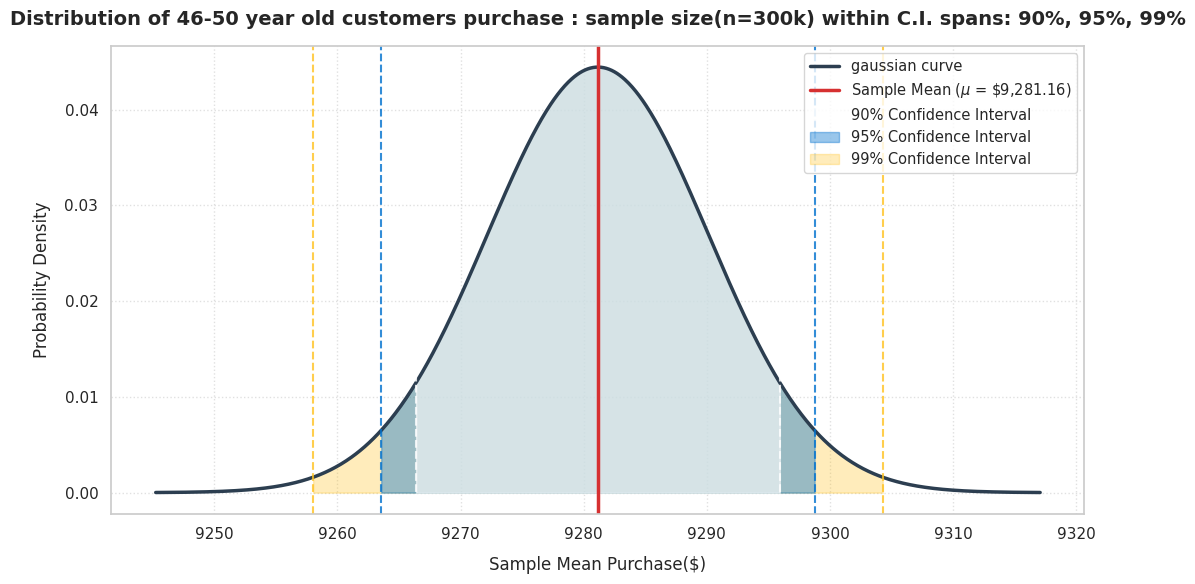

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '46-50')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '46-50'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 46-50 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['46-50']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000 46-50              90%      9276.68          6.9582      9265.24      9288.13           22.89
         500000 46-50              95%      9276.68          6.9582      9263.04      9290.32           27.28
         500000 46-50              99%      9276.68          6.9582      9258.76      9294.61           35.85


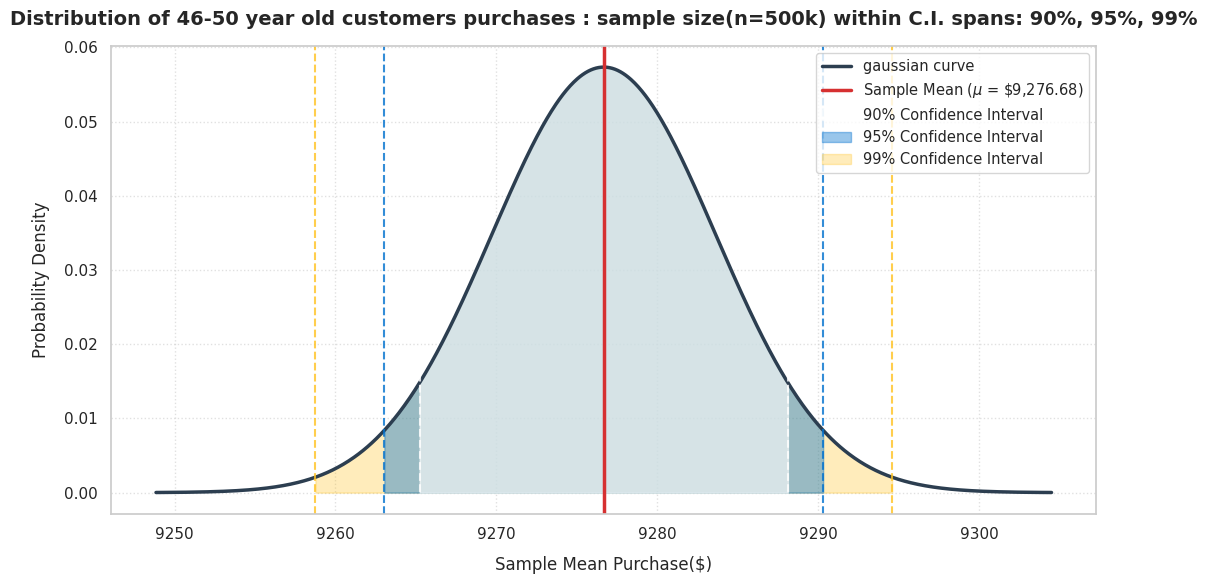

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '46-50')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '46-50'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 46-50 year old customers purchases : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['51-55']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000 51-55              90%      9635.56         15.9264      9609.37      9661.76           52.39
         100000 51-55              95%      9635.56         15.9264      9604.35      9666.78           62.43
         100000 51-55              99%      9635.56         15.9264      9594.54      9676.59           82.05


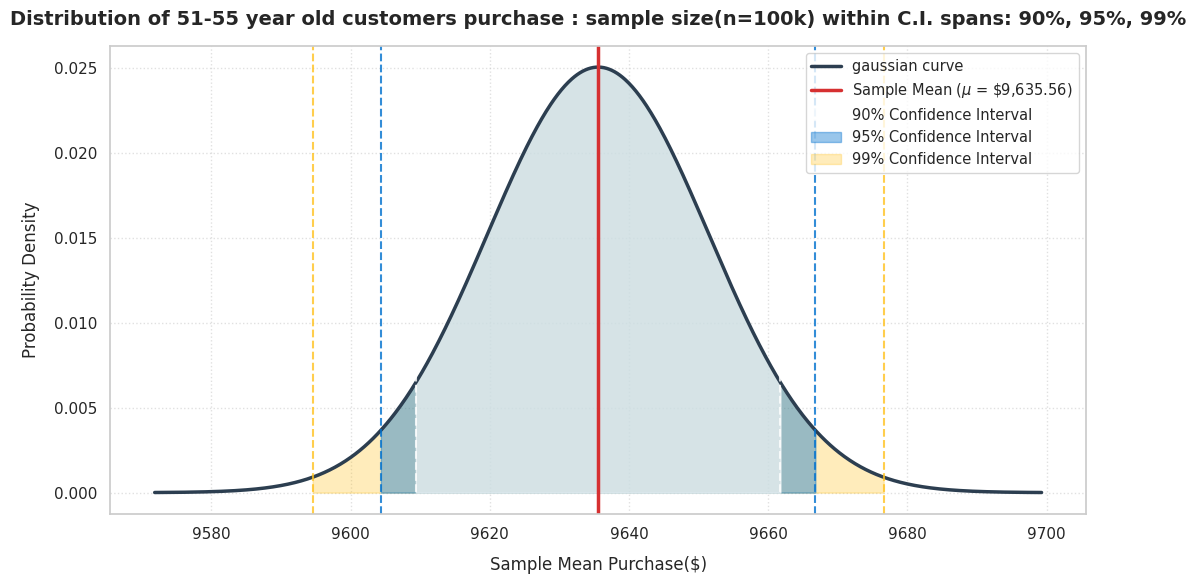

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '51-55')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '46-50'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 51-55 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [300000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['51-55']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000 51-55              90%       9621.7           9.182      9606.60      9636.80           30.21
         300000 51-55              95%       9621.7           9.182      9603.70      9639.70           35.99
         300000 51-55              99%       9621.7           9.182      9598.05      9645.35           47.30


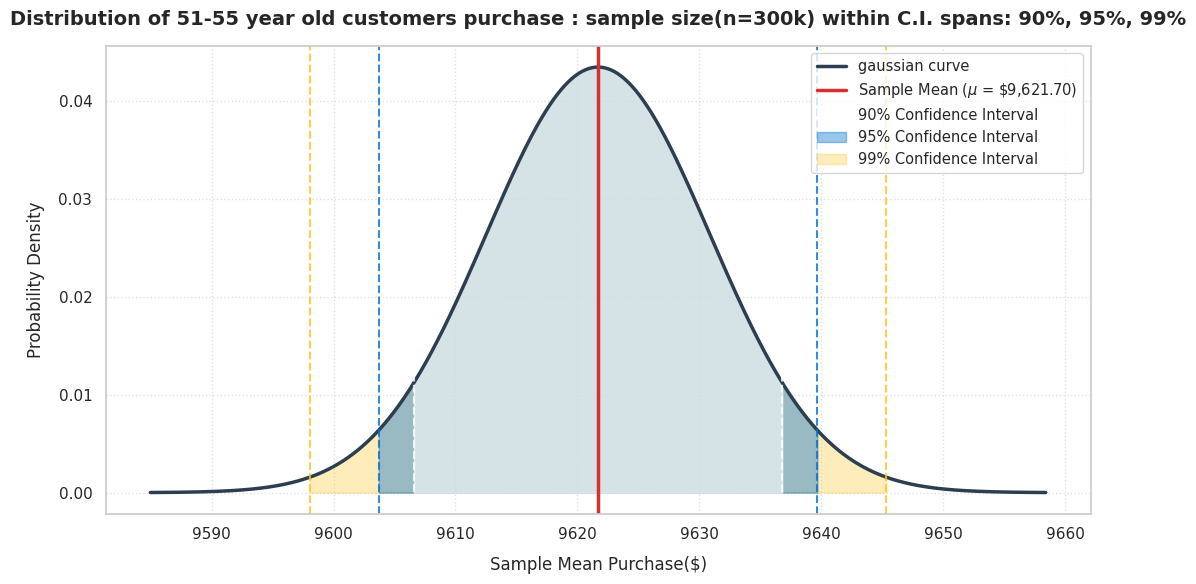

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '51-55')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '46-50'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 51-55 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['51-55']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n)   Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000 51-55              90%      9618.85          7.1066      9607.16      9630.54           23.38
         500000 51-55              95%      9618.85          7.1066      9604.92      9632.78           27.86
         500000 51-55              99%      9618.85          7.1066      9600.55      9637.16           36.61


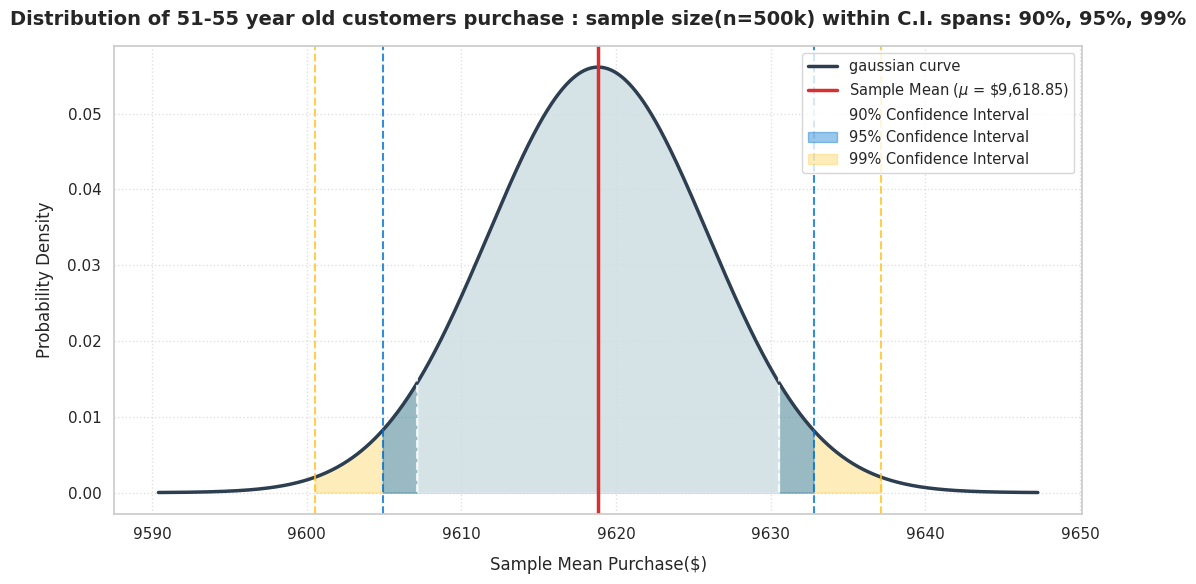

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '51-55')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '46-50'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 51-55 year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [100000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['55+']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         100000 55+              90%      9482.46         15.5568      9456.87      9508.05           51.18
         100000 55+              95%      9482.46         15.5568      9451.97      9512.95           60.98
         100000 55+              99%      9482.46         15.5568      9442.39      9522.53           80.14


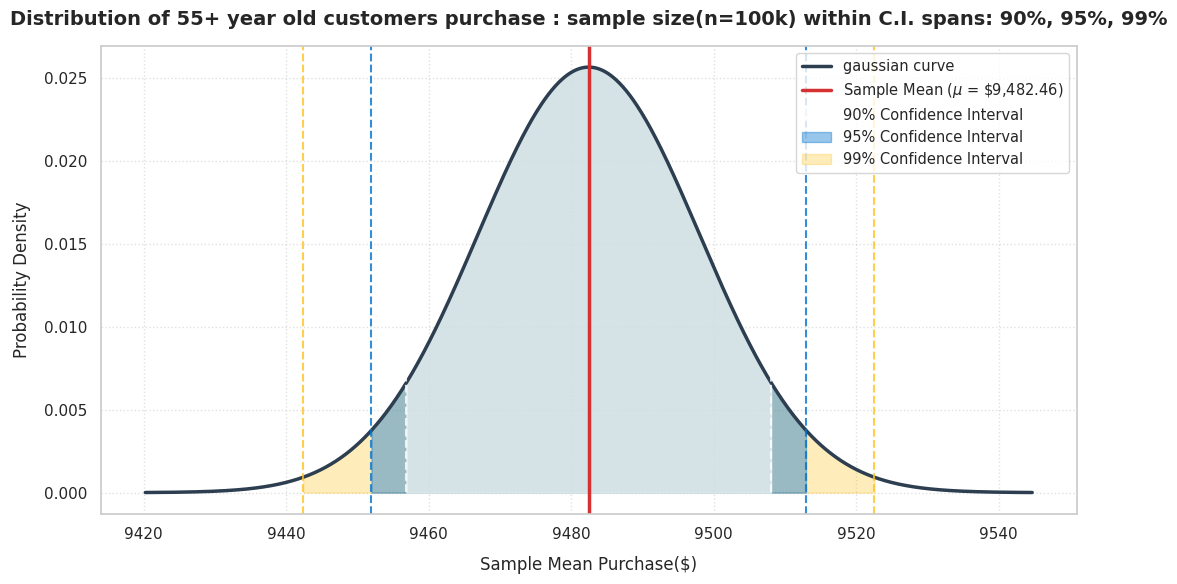

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 100000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '55+')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '46-50'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 55+ year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [300000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['55+']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         300000 55+              90%      9449.97          8.9954      9435.18      9464.77           29.59
         300000 55+              95%      9449.97          8.9954      9432.34      9467.60           35.26
         300000 55+              99%      9449.97          8.9954      9426.80      9473.14           46.34


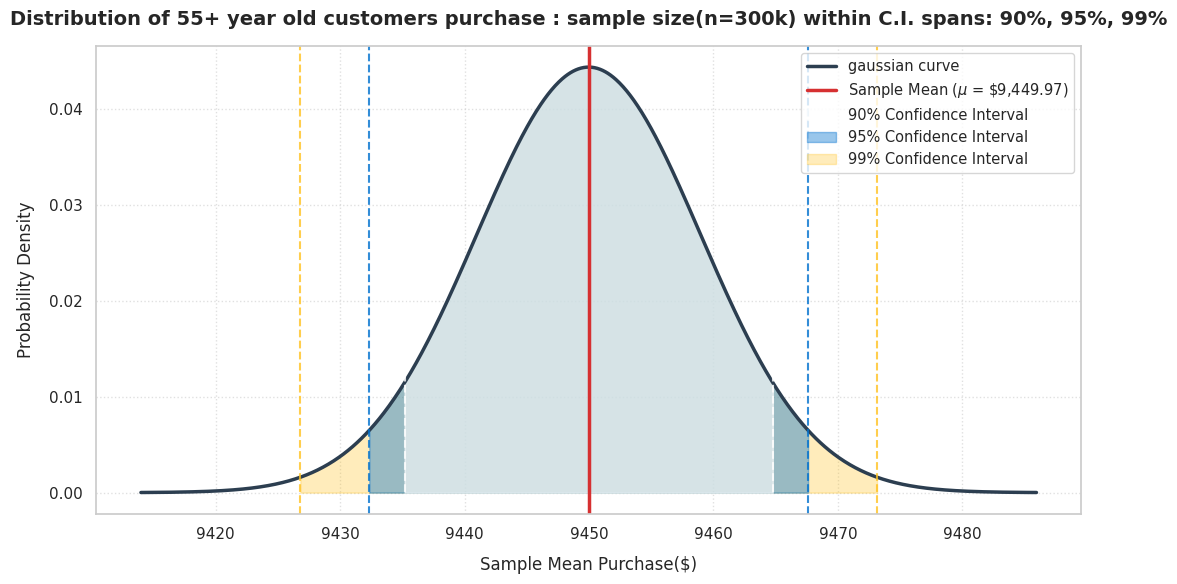

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 300000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '55+')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '46-50'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 55+ year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

In [ ]:
import scipy.stats as stats
sample_sizes = [500000]
confidence_levels = [0.90, 0.95, 0.99]
results = []
for n in sample_sizes:
    for age in ['55+']:

        age_pop = walmart[walmart['Age'] == age]['Purchase']

        sample = age_pop.sample(n=n, replace=True, random_state=42)

        sample_mean = sample.mean()
        sample_std = sample.std()
        std_err = sample_std / np.sqrt(n)

        for cl in confidence_levels:

            z_critical = stats.norm.ppf((1 + cl) / 2)
            margin_of_error = z_critical * std_err

            lower_bound = sample_mean - margin_of_error
            upper_bound = sample_mean + margin_of_error
            interval_width = upper_bound - lower_bound

            results.append({
                'Sample Size(n)': n,
                'Age': age,
                'Confidence Level': f"{int(cl*100)}%",
                'Sample Mean': round(sample_mean, 2),
                'Standard Error': round(std_err, 4),
                'Lower Bound': round(lower_bound, 2),
                'Upper Bound': round(upper_bound, 2),
                'Interval Width': round(interval_width, 2)
            })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Sample Size(n) Age Confidence Level  Sample Mean  Standard Error  Lower Bound  Upper Bound  Interval Width
         500000 55+              90%      9443.39          6.9676      9431.93      9454.85           22.92
         500000 55+              95%      9443.39          6.9676      9429.74      9457.05           27.31
         500000 55+              99%      9443.39          6.9676      9425.45      9461.34           35.89


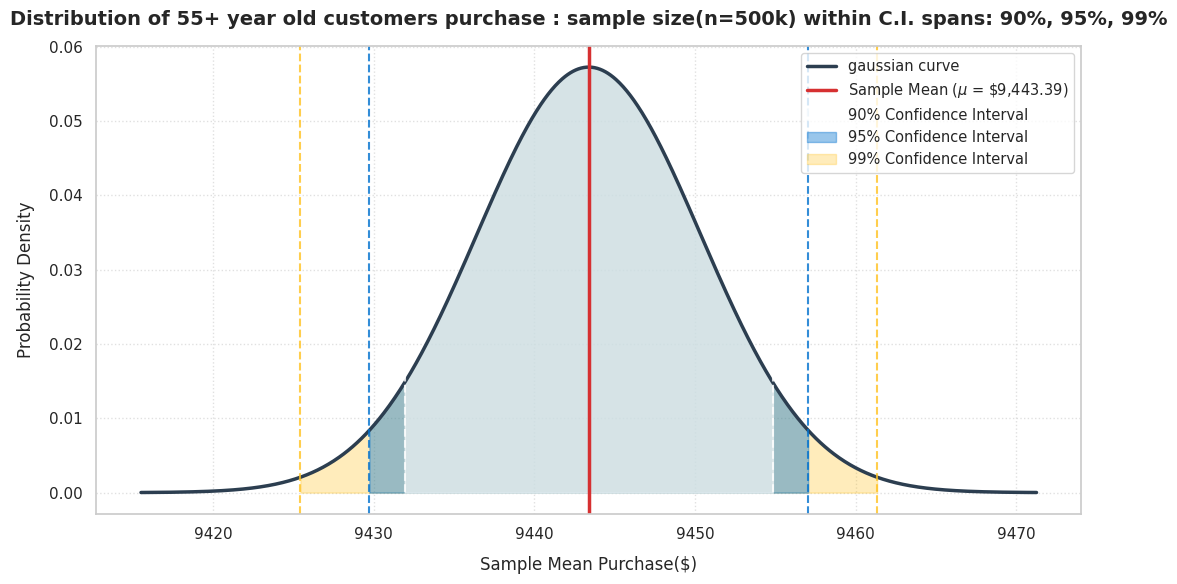

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sample_size_to_plot = 500000
fig, ax = plt.subplots(figsize=(11, 6))

f_results = df_results[(df_results['Sample Size(n)'] == sample_size_to_plot) & (df_results['Age'] == '55+')]

if f_results.empty:
    print(f"No data found for Sample Size(n) = {sample_size_to_plot} and Age = '46-50'. Please choose an available sample size.")
else:
    sample_mean = f_results['Sample Mean'].values[0]
    sem = f_results['Standard Error'].values[0]

    x = np.linspace(sample_mean - 4 * std_err, sample_mean + 4 * std_err, 1000)
    y = stats.norm.pdf(x, sample_mean, std_err)

    ax.plot(x, y, color='#2c3e50', lw=2.5, label = 'gaussian curve')

    intervals = [0.99, 0.95, 0.90]
    colors = ['#FFC220', '#0071CE', '#FFFFFF']
    alphas = [0.3, 0.4, 0.6]

    for cl, color, alpha in zip(intervals, colors, alphas):
        z_critical = stats.norm.ppf((1 + cl) / 2)
        moe = z_critical * std_err
        lower = sample_mean - moe
        upper = sample_mean + moe

        x_fill = np.linspace(lower, upper, 500)
        y_fill = stats.norm.pdf(x_fill, sample_mean, std_err)

        ax.fill_between(x_fill, y_fill, color=color, alpha=alpha,
                        label=f'{int(cl*100)}% Confidence Interval')

        ax.axvline(lower, color=color, linestyle='--', lw=1.5, alpha=0.8)
        ax.axvline(upper, color=color, linestyle='--', lw=1.5, alpha=0.8)

    ax.axvline(sample_mean, color='#d63031', linestyle='-', lw=2.5,
               label=fr'Sample Mean ($\mu$ = \${sample_mean:,.2f})')

    ax.set_title(f'Distribution of 55+ year old customers purchase : sample size(n={sample_size_to_plot/1000:.0f}k) within C.I. spans: 90%, 95%, 99%',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Sample Mean Purchase($)', fontsize=12, labelpad=10)
    ax.set_ylabel('Probability Density', fontsize=12, labelpad=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    handles, labels = ax.get_legend_handles_labels()
    ordered_indices = [0, 4, 3, 2, 1]
    ax.legend([handles[i] for i in ordered_indices], [labels[i] for i in ordered_indices],
              loc='upper right', fontsize=10.5, frameon=True, facecolor='white')

    plt.tight_layout()
    plt.show()

**Using the sample of all age groups we'll calculate the interval within which the average spending of 50 million customers may lie.**

**Let's check if the confidence intervals of all age group's average spending are overlapping or not overlapping.**

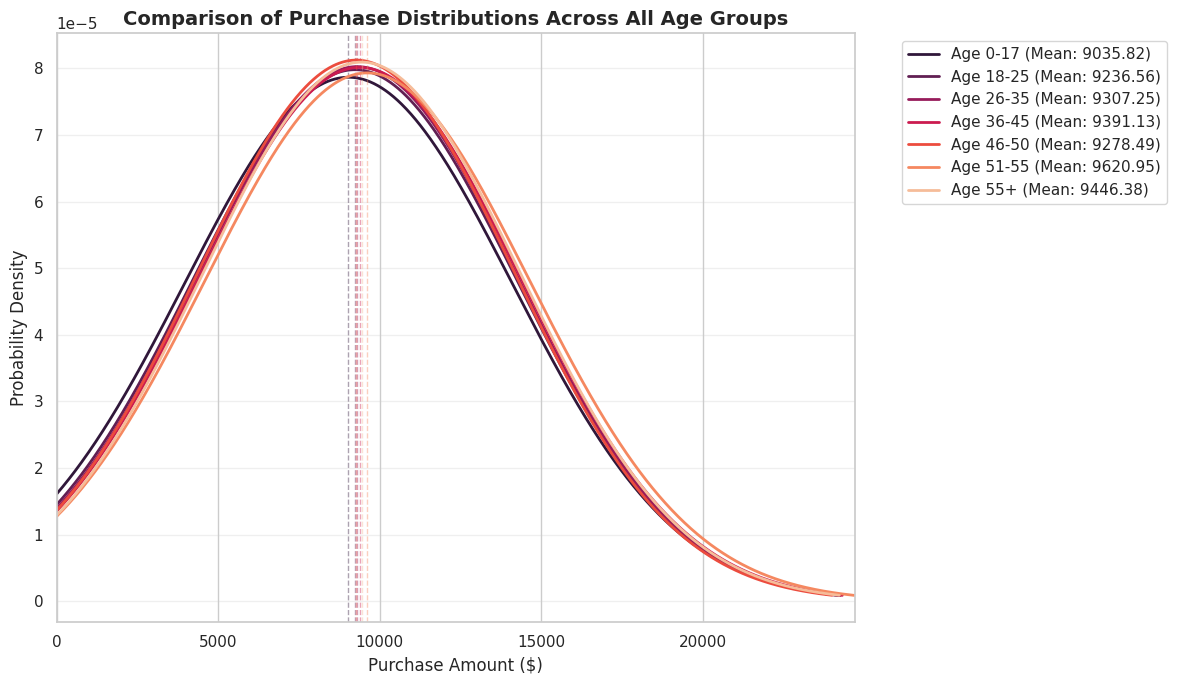

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# 1. Sort the unique age groups so the legend/plot order makes chronological sense
age_groups = sorted(walmart['Age'].unique())

# 2. Set up the figure and a color palette for multiple lines
plt.figure(figsize=(12, 7))
colors = sns.color_palette("rocket", len(age_groups)) # Smooth gradient palette

max_x_value = 0

# 3. Loop through each age group and plot its distribution curve
for i, age in enumerate(age_groups):
    # Filter data for the specific age group
    age_data = walmart[walmart['Age'] == age]['Purchase']

    # Calculate group-specific mu (mean) and sigma (std deviation)
    mu = age_data.mean()
    sigma = age_data.std()

    # Generate x-axis values tailored to this curve
    x = np.linspace(0, mu + 3*sigma, 1000)
    max_x_value = max(max_x_value, x.max()) # Track max X to keep the plot bounded

    # Plot the normal distribution curve
    plt.plot(x, stats.norm.pdf(x, mu, sigma), label=f'Age {age} (Mean: {mu:.2f})', color=colors[i], lw=2)

    # Optional: Add subtle vertical lines for the means (comment out if it looks too crowded)
    plt.axvline(mu, color=colors[i], linestyle='--', alpha=0.4, lw=1)

# 4. Final plot styling
plt.title('Comparison of Purchase Distributions Across All Age Groups', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Amount ($)')
plt.ylabel('Probability Density')
plt.xlim(0, max_x_value)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside to prevent clutter
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

---

# **Conclusion: age group based analysis**

---
* **Average number of purchases of customers in age group 0-17 is 69.28**

* **Average number of purchases of customers in age group 18-25 is 93.23**

* **Average number of purchase of customers in age group 26-25 is 106.96**

* **Average number of purchase of customers in age group 36-45 is 94.27**

* **Average number of purchase of customers in age group 46-50 is 86.07**

* **Average number of purchase of customers in age group 51-55 is 80.04**

* **Average number of purchase of customers in age group above 55 is 57.81**

* **Customers between the ages 18-45 contributes to 72.7%  unique customers**

  * **18-25 year olds = 18.1% customers**

  * **26-35 year olds = 34.8% customers**

  * **36-45 year olds = 19.8% customers**

* **Customers between the ages 18-45 contributes to 80% total customers**

  * **18.1% 18-25 year olds = 18.1% of total customers**

  * **34.8% 26-35 year olds = 39.9% of total customers**

  * **19.8% 36-45 year olds = 20% of total customers**

* **Average purchase amount for customers in age group:**

  * **0-17 is 8933.46**

  * **18-25 is 9169.66**

  * **26-35 is 9252.69**

  * **36-45 is 9331.35**

  * **46-50 is 9208.63**

  * **51-55 is 9534.81**

  * **above 55 is 9336.28**

* **95% confidence interval for customers 0-17 year olds purchase: 8851.94 to 9014.98**

* **95% confidence interval for customers 18-25 year olds purchase: 9138.40 to 9200.91**

* **95% confidence interval for customers 26-35 year olds purchase: 9231.73 to 9273.64**

* **95% confidence interval for customers 36-45 year olds purchase: 9301.66 to 9361.03**

* **95% confidence interval for customers 46-50 year olds purchase: 9163.08 to 9254.16**

* **95% confidence interval for customers 51-55 year olds purchase: 9483.99 to 9585.62**


* **95% confidence interval for customers above 55 year olds purchase: 9269.29 to 9403.26**


---
# **Final verdict & recommendatation:**
---

Based on extensive Exploratory Data Analysis (EDA) of this 550k-record dataset, we can translate these statistical insights into actionable, high-impact business strategies for Walmart.

Here are the key recommendations and strategic action items tailored to our findings.

---

##**Executive Recommendations & Action Items**

---
**1. Shift from Demographic Targeting to Volume-Based Retention**

---

**The Insight:**

Both Gender and Marital Status are incredibly weak predictors of how much an individual spends per transaction. The average ticket sizes across these groups are tightly clustered. However, the **volume** of transactions is highly skewed (e.g., Men represent 75% of total transactions).

* **Action Item:**

  * **Stop segmenting promotional messaging by marital status or gender identity for general inventory.** Instead, design a Unified Core Marketing Strategy targeting general purchasing power.

  * Shift marketing budgets away from demographic acquisition and toward **Frequency and Retention Campaigns** (e.g., loyalty rewards for repeat purchases) to capitalize on the high average transaction rate (93 purchases per customer).

---
**2. Double-Down on the "*Power Demographics*" (Ages 18–45)**

---

**The Insight:**

The 26–35 age group is the undisputed core powerhouse, driving 39.9% of total customers and the highest average purchase frequency (106.9 purchases/customer). The surrounding brackets (18–25 and 36–45) bring the total contribution of this 18–45 super-group to **80% of total transactions**.

* **Action Item:** Allocate **70–80% of the digital ad spend** to target the 18–45 demographic, focusing heavily on mobile-first campaigns, app-exclusive deals, and frictionless checkout (omnichannel retail).
* **Action Item:** Tailor the product catalog in **City Category B** (your highest spending region) to match the lifestyle needs of 26–35 year-olds (e.g., career growth, young families, home setup).

---
**3. Implement Dynamic Inventory Buffers for Single Customers**

---

**The Insight:**

While married and single customers spend nearly the exact same amount on average (~$9,260), single customers exhibit a much higher variance (wider spread, unpredictable buying habits ranging from tiny impulse buys to major retail hauls).

* **Action Item:** Implement an **Agile Inventory Buffer Plan** for products heavily associated with single demographics. Increase stock buffers by **10–15%** for these lines to mitigate out-of-stock risks during unpredictable spending surges.
* **Action Item:** Utilize married customers' consistency (narrower variance) to optimize supply chain forecasting and auto-replenishment cycles for household and family-centric goods.

---
**4. Capitalize on the "Hidden Premium" Age Group (51–55)**

---

**The Insight:**

While the 51–55 age bracket makes fewer transactions overall (~80 per customer), they command the **highest average purchase amount ($9,534.81)** with a statistically distinct, non-overlapping 95% confidence interval ($9,483.99 to $9,585.62).

* **Action Item:** Roll out a **"Premium/High-Ticket" cross-selling strategy** specifically triggered for the 51–55 demographic.
* **Action Item:** Target this age bracket with bundle offers, higher-end electronics, home improvement, or wellness products to maximize their superior purchasing power per visit.

---
**5. Optimize Product Placement & Occupation-Based Perks**

---

**The Insight:**

Product categories 1, 5, and 8 are high-velocity drivers, while categories 9, 14, and 17 lag significantly. Furthermore, specific customer occupations (0, 4, 7) drive the highest spending.

* **Action Item:** Use Categories 1, 5, and 8 as **"Loss Leaders"** or prominent front-of-store/homepage features to drive foot traffic. Bundle underperforming categories (9, 14, 17) with these high-frequency items using personalized discounts.
* **Action Item:** Launch **Corporate/B2B Affinity Programs** or targeted corporate discounts specifically tailored to industries matching Occupations 0, 4, and 7 to lock in their high-spending loyalty.

---
**6. Target the High-Value Outliers**

---

**The Insight:**

The data is right-skewed with a maximum purchase of 24k, a high standard deviation (5k), and the top 25% of spenders buying items above 12k.

* **Action Item:** Create a **VIP Tier** within the Walmart loyalty ecosystem. When a customer's transaction exceeds the 75th percentile ($12k threshold), automatically trigger high-value incentives, personal shopper perks, or free premium shipping to keep these "whale" accounts active.

---
